In [1]:
# Replace Lorenz-based data generation with WallModelDataHandler-based loader
import os
import sys
import torch
import numpy as np
import json
import pickle

# Make plots interactive using widget backend (recommended for VS Code)
import matplotlib.pyplot as plt

# Use legacy Keras for compatibility with tf-models-official layers:
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf
import official.nlp.modeling.layers as nlp_layers

# Add src path to import WallModel modules
sys.path.insert(0, os.path.abspath('./src'))
sys.path.insert(0, os.path.abspath('./src_err'))

from data_handler import WallModelDataHandler, COLUMN_MAP
from parsing_wm import parse_toml_config
from wall_model import WallModel
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


2025-08-21 05:53:25.453551: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-21 05:53:25.470951: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755770005.490991 1107454 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755770005.497113 1107454 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755770005.514738 1107454 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# #Check added paths
# for i, p in enumerate(sys.path):
#     print(f"{i}: {p}")

In [3]:
# Load configuration
config_file = 'input2_example.toml'  # Replace with desired config file name
config = parse_toml_config(os.path.join('inputfiles', config_file))

# Disable wandb logging
config['general']['UseWandb'] = True

# Allow user to specify InputScaling
input_scaling_value = 2  # Set as needed (based on COLUMN_MAP)
config['model']['inputs'] = {'InputScaling': input_scaling_value}

# Set GPU device if available
gpu_num = config.get('general', {}).get('GpuNum', 0)
device = torch.device(f"cuda:{gpu_num}" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda:3


In [4]:
print(config)

{'general': {'Verbose': 1, 'UseWandb': True, 'Save': True, 'SaveDir': './models', 'GpuNum': 3, 'WandbName': 'Input2_example'}, 'data': {'CH': 1, 'SYN': 0, 'gaussian_2M_MAPG': 0, 'gaussian_2M_APG': 0, 'gaussian_2M_FPG': 0, 'gaussian_2M_SEP': 0, 'bub_K': 1, 'TBL': [-4, -1, 10], 'FS_ZPG': 1, 'FS_APG': 1, 'FS_FPG': 1, 'upy': 0.15, 'partition': {'TrainRatio': 0.8, 'RandomSplitWM': True}}, 'model': {'HiddenLayers': [40, 40, 40, 40], 'OutputDim': 1, 'Activation': 'relu', 'inputs': {'InputScaling': 2}, 'outputs': {'OutputScaling': 1}, 'LDS': {'lds': 0, 'reweight': 'sqrt_inv', 'kernel': 'gaussian', 'ks': 5, 'sigma': 2, 'num_bins': 100}, 'FDS': {'fds': 0, 'num_layers': 2, 'num_neurons': 32, 'kernel': 'gaussian', 'ks': 5, 'sigma': 2}, 'FW': {'fw': 0}, 'weights': {'custom': 1}}, 'training': {'LossFunction': 'Huber', 'optimizer': {'Type': 'Adam', 'LearningRate': 0.0008, 'WeightDecay': 1e-05, 'Momentum': 0.9}, 'scheduler': {'Type': 'plateau', 'Patience': 25, 'Factor': 0.98, 'StepSize': 30, 'Gamma': 

In [5]:
# make plots interactive using widget or notebook backend
# (recommended for VS Code)

# %matplotlib widget
# import matplotlib
# print(matplotlib.get_backend())

# Load Training data and train/load Baseline model

In [6]:
# Control whether to train or load existing model
train_flag = 0  # Set to 0 to load from checkpoint instead of training

# Initialize WallModel
model = None
if train_flag:
    model = WallModel(config)
    model.device = device
    model.load_data()
else:
    # checkpoint_path = os.path.join("./models", config.get('general', {}).get('ModelCheckpoint', 'cleaned_up_model_1.pth'))
    checkpoint_path = os.path.join("./models", config.get('general', {}).get('ModelCheckpoint', 'NN_input2_withGaussian_0618_v2.pth'))
    model = WallModel.load(checkpoint_path, device=device)
    # model.override_config(config, checkpoint_path)
    model.load_data()  # This is required even when loading a trained model

# Extract data for downstream use (e.g., error modeling)
X_train = model.input_train
y_train = model.output_train
X_valid = model.input_valid
y_valid = model.output_valid
flow_types = model.flow_type

# Assign fixed class labels per dataset
unique_flows = np.unique(flow_types)
flow_to_label = {flow: i for i, flow in enumerate(unique_flows)}
labels_train = np.array([flow_to_label[ft] for ft in flow_types[model.train_index]])
labels_valid = np.array([flow_to_label[ft] for ft in flow_types[model.valid_index]])


# # Append 2 gaussian clouds of dummy training datasets at (u1,up,u2)=(10000,0,10000) and (u1,up,u2)=(-10000,0,-10000)
# num_dummy = 1000
# centers = [(40000, 0, 40000), (-40000, 0, -40000)]
# std = 50

# dummy_inputs = []
# dummy_labels = []
# for i, center in enumerate(centers):
#     cloud = np.random.normal(loc=center, scale=std, size=(num_dummy, 3))
#     dummy_inputs.append(cloud)
#     # assign new unique label for each dummy cloud (not overlapping with real classes)
#     dummy_labels.append(np.full(num_dummy, len(np.unique(flow_types)) + i, dtype=int))

# dummy_inputs = np.vstack(dummy_inputs)
# dummy_labels = np.concatenate(dummy_labels)

# # append to training data
# X_train = np.vstack([X_train, dummy_inputs])
# X_valid = np.vstack([X_valid, dummy_inputs])
# labels_train = np.concatenate([labels_train, dummy_labels])
# labels_valid = np.concatenate([labels_valid, dummy_labels])

# # # Append dummy Gaussian clouds to training and validation data
# # np.random.seed(0)
# # dummy_train = np.random.normal(loc=[10000, 0, 10000], scale=50, size=(1000, 3))
# # dummy_valid = np.random.normal(loc=[-10000, 0, -10000], scale=50, size=(1000, 3))

# # X_train = np.vstack([X_train, dummy_train])
# # X_valid = np.vstack([X_valid, dummy_valid])

# # Add dummy flow types to label mapping
# flow_to_label['dummy1'] = len(flow_to_label)
# flow_to_label['dummy2'] = len(flow_to_label)

# # # Append corresponding labels
# # labels_train = np.concatenate([labels_train, np.full(len(dummy_train), flow_to_label['dummy1'])])
# # labels_valid = np.concatenate([labels_valid, np.full(len(dummy_valid), flow_to_label['dummy2'])])


print("Training set:", X_train.shape, y_train.shape, labels_train.shape)
print("Validation set:", X_valid.shape, y_valid.shape, labels_valid.shape)
print("Label mapping:", flow_to_label)

Creating model with input dimension: 3
--------------------------------------------------
Model summary:
  Input dimension: 3
  Hidden layers: [40, 40, 40, 40]
  Output dimension: 1
  Activation function: relu
  Model layers: [Linear(in_features=3, out_features=40, bias=True), ReLU(), Linear(in_features=40, out_features=40, bias=True), ReLU(), Linear(in_features=40, out_features=40, bias=True), ReLU(), Linear(in_features=40, out_features=40, bias=True), ReLU(), Linear(in_features=40, out_features=1, bias=True)]
  Model device: cuda:3
  Model type: <class 'NoneType'>
--------------------------------------------------
Using input scaling mode: 2
Reading HDF5 file: ./data/CH_data.h5
Filtering CH with upy_max=0.15...
  Filtered dataset CH: 719 -> 719 points
  Processed 548 samples from CH with 3 input dimensions (Scaling Mode: 2)
--------------------------------------------------
Reading HDF5 file: ./data/SYN_data.h5
Filtering SYN with upy_max=0.15...
  Filtered dataset SYN: 400 -> 400 poi

In [7]:
config_loaded_model = model.config
print(json.dumps(config_loaded_model, indent=4))

{
    "general": {
        "Verbose": 1,
        "UseWandb": true,
        "Save": true,
        "SaveDir": "./models",
        "GpuNum": 3,
        "WandbName": "Input2_with_Gaussian_0618_v2"
    },
    "data": {
        "CH": 1,
        "SYN": 1,
        "gaussian_2M_MAPG": 1,
        "gaussian_2M_APG": 1,
        "gaussian_2M_FPG": 1,
        "gaussian_2M_SEP": 1,
        "bub_K": 1,
        "TBL": [
            -4,
            -3,
            -2,
            -1,
            5,
            10,
            15,
            20
        ],
        "FS_ZPG": 1,
        "FS_APG": 1,
        "FS_FPG": 1,
        "upy": 0.15,
        "partition": {
            "TrainRatio": 0.8,
            "RandomSplitWM": true
        }
    },
    "model": {
        "HiddenLayers": [
            40,
            40,
            40,
            40
        ],
        "OutputDim": 1,
        "Activation": "relu",
        "inputs": {
            "InputScaling": 2
        },
        "outputs": {
            "Out

In [8]:
# Normalize X_train and X_valid using the mean and standard deviation of X_train for each input dimension
mean_X_train = np.mean(X_train, axis=0, keepdims=True)
std_X_train = np.std(X_train, axis=0, keepdims=True)
X_train_norm = (X_train - mean_X_train) / std_X_train
X_valid_norm = (X_valid - mean_X_train) / std_X_train

print('training mean: ',mean_X_train)
print('training std: ',std_X_train)

training mean:  [[1236.36086252    7.91767513 1508.45803987]]
training std:  [[17461.77217133    21.64013845 17959.2539754 ]]


In [9]:
# Train the model
if train_flag:
    model.train()

# Load Test data and Additional data (Error model)

In [10]:
# Generate Test data
from wall_model_cases import TURB_CASES, TURB_CASES_TREE, print_dataset_tree
import Levenshtein

# test_datasets = ['backstep']

test_datasets = ["CH", "bub_K", "FS_ZPG", "FS_APG", "FS_FPG",                        # Full baseline set
                 "TBL_5", "TBL_10", "TBL_15", "TBL_20",
                 "TBL_-1", "TBL_-2", "TBL_-3", "TBL_-4",
                 "gaussian_2M_APG", "gaussian_2M_FPG", "gaussian_2M_SEP", "gaussian_2M_MAPG",
                 'curved_TBL',
                 'spinning_Driver_as1', 'spinning_Driver_cs0', 'spinning_Driver_cs1', 'spinning_Driver_ds0', 'spinning_Driver_ds1',
                 'transition_Coupland_t3am', 'transition_Coupland_t3a', 'transition_Coupland_t3b' , 'transition_Coupland_t3c1','transition_Coupland_t3c2', 'transition_Coupland_t3c3', 'transition_Coupland_t3c4', 'transition_Coupland_t3c5',]
                #  'backstep','hump','ph_B'] #additional cases with error ~10-20% 

# test_datasets = ["TBL_5", "TBL_10", "TBL_15", "TBL_20",
#                  "TBL_-1", "TBL_-2", "TBL_-3", "TBL_-4"]

# test_datasets = ["TBL_15"]

# test_datasets = ["naca_0012", "bend", "gaussian_2M_FPG", "gaussian_1M_APG"]
# test_datasets = ["gaussian_2M_APG", "gaussian_2M_FPG", "gaussian_2M_SEP"]

X_test_all = []
y_test_all = []
unnormalized_inputs_test_all = []   # 0: y,   1: u,   2: nu,   3: utau
flow_type_test_all = []

for test_dataset in test_datasets:
    if test_dataset not in TURB_CASES:
        print(f"Warning: '{test_dataset}' is not a valid dataset.")
        continue

    # results = model.test_external_dataset(
    #     dataset_key=test_dataset,
    #     tauw=True,
    #     # save_path='./results',
    #     LogTransform=config.get('training', {}).get('LogTransform', False)
    # )
    # print(f"Results for {test_dataset}:", results)

    # if results is not None:
    # Retrieve test inputs and targets for error model training
    inputs, targets, unnormalized_inputs_test, flow_type_test = model.data_handler.load_external_dataset(test_dataset)
    X_test_all.append(inputs)
    y_test_all.append(targets.flatten())
    unnormalized_inputs_test_all.append(unnormalized_inputs_test[:, :4])  # only extract first 4 columns
    flow_type_test_all.append(flow_type_test)

# --- Concatenate all test sets ---
X_test_all = np.vstack(X_test_all)
y_test_all = np.concatenate(y_test_all)
unnormalized_inputs_test_all = np.vstack(unnormalized_inputs_test_all)

# For flow_type_test_all Pad shorter arrays with NaN or some other value
max_cols = max(arr.shape[1] for arr in flow_type_test_all)
padded_arrays = []
for arr in flow_type_test_all:
    if arr.shape[1] < max_cols:
        padding = np.full((arr.shape[0], max_cols - arr.shape[1]), np.nan)
        arr = np.hstack([arr, padding])
    padded_arrays.append(arr)
flow_type_test_all = np.concatenate(padded_arrays)
# flow_type_test_all = np.concatenate(flow_type_test_all)

# Normalize test data using training set statistics
X_test_norm  = (X_test_all - mean_X_train) / std_X_train

print("Final test dataset shape:", X_test_all.shape, y_test_all.shape)

--------------------------------------------------
Filtered external dataset CH: 719 -> 548 points
Loaded external dataset CH with input scaling mode 2, input dims 3
--------------------------------------------------
Filtered external dataset bub_K: 21609 -> 21609 points
Loaded external dataset bub_K with input scaling mode 2, input dims 3


--------------------------------------------------
Filtered external dataset FS_ZPG: 1700 -> 1700 points
Loaded external dataset FS_ZPG with input scaling mode 2, input dims 3
--------------------------------------------------
Filtered external dataset FS_APG: 16700 -> 16700 points
Loaded external dataset FS_APG with input scaling mode 2, input dims 3
--------------------------------------------------
Filtered external dataset FS_FPG: 19700 -> 19700 points
Loaded external dataset FS_FPG with input scaling mode 2, input dims 3
--------------------------------------------------
Filtered external dataset TBL_5: 47243 -> 42773 points
Loaded external dataset TBL_5 with input scaling mode 2, input dims 3
--------------------------------------------------
Filtered external dataset TBL_10: 169040 -> 152495 points
Loaded external dataset TBL_10 with input scaling mode 2, input dims 3
--------------------------------------------------
Filtered external dataset TBL_15: 162059 -> 152143 points
Loa

In [11]:
# Generate additional datasets for error model training

# add_datasets = ["TBL_5", "TBL_10", "TBL_15", "TBL_20"]
# add_datasets = ["naca_0012", "bend", "gaussian_1M_FPG", "gaussian_1M_APG"]
# add_datasets = ["gaussian_2M_APG", "gaussian_2M_FPG", "gaussian_2M_SEP"] 
add_datasets = ['spinning_Driver_as1', 'spinning_Driver_cs0', 'spinning_Driver_cs1', 'spinning_Driver_ds0', 'spinning_Driver_ds1',
                 'transition_Coupland_t3am', 'transition_Coupland_t3a', 'transition_Coupland_t3b' , 'transition_Coupland_t3c1','transition_Coupland_t3c2', 'transition_Coupland_t3c3', 'transition_Coupland_t3c4', 'transition_Coupland_t3c5',
                 'curved_TBL',]
                #  'backstep','hump','ph_B'] #additional cases with error ~10-20% 
X_extra = []
y_extra = []
unnormalized_inputs_extra = []

for test_dataset in add_datasets:
    if test_dataset not in TURB_CASES:
        print(f"Warning: '{test_dataset}' is not a valid dataset.")
        continue

    # results = model.test_external_dataset(
    #     dataset_key=test_dataset,
    #     tauw=True,
    #     save_path='./results',
    #     LogTransform=config.get('training', {}).get('LogTransform', False)
    # )
    # print(f"Results for {test_dataset}:", results)

    # Retrieve test inputs and targets for error model training
    inputs, targets, unnorm_inputs_, flow_type_ = model.data_handler.load_external_dataset(test_dataset)
    X_extra.append(inputs)
    y_extra.append(targets.flatten())
    unnormalized_inputs_extra.append(unnorm_inputs_[:, :4])

# --- Concatenate all test sets ---
X_extra = np.vstack(X_extra)
y_extra = np.concatenate(y_extra)
unnormalized_inputs_extra = np.vstack(unnormalized_inputs_extra)

# Create a temporary handler for splitting
temp_handler = WallModelDataHandler(config=config)
temp_handler.input  = X_extra
temp_handler.output = y_extra

X_extra_train, y_extra_train, X_extra_valid, y_extra_valid = temp_handler.split_data(train_ratio=0.8, random_split=True)

print("Additional training dataset shape:", X_extra_train.shape, y_extra_train.shape)
print("Additional validation dataset shape:", X_extra_valid.shape, y_extra_valid.shape)

--------------------------------------------------
Filtered external dataset spinning_Driver_as1: 110 -> 92 points
Loaded external dataset spinning_Driver_as1 with input scaling mode 2, input dims 3
--------------------------------------------------
Filtered external dataset spinning_Driver_cs0: 74 -> 65 points
Loaded external dataset spinning_Driver_cs0 with input scaling mode 2, input dims 3
--------------------------------------------------
Filtered external dataset spinning_Driver_cs1: 105 -> 93 points
Loaded external dataset spinning_Driver_cs1 with input scaling mode 2, input dims 3
--------------------------------------------------
Filtered external dataset spinning_Driver_ds0: 32 -> 25 points
Loaded external dataset spinning_Driver_ds0 with input scaling mode 2, input dims 3
--------------------------------------------------
Filtered external dataset spinning_Driver_ds1: 104 -> 92 points
Loaded external dataset spinning_Driver_ds1 with input scaling mode 2, input dims 3
-------

# Classifier and Confidence Model

In [12]:
# --- SNGP Classifier ---

class DeepResNet(tf.keras.Model):
    def __init__(self, num_classes, num_layers=3, num_hidden=128, dropout_rate=0.1, **classifier_kwargs):
        super().__init__()
        self.num_hidden = num_hidden
        self.num_layers = num_layers
        self.dropout_rate = dropout_rate
        self.classifier_kwargs = classifier_kwargs
        self.input_layer = tf.keras.layers.Dense(self.num_hidden, trainable=False, name="input_layer")
        self.dense_layers = [self.make_dense_layer() for _ in range(num_layers)]
        self.classifier = self.make_output_layer(num_classes)
    def call(self, inputs, training=False):
        hidden = self.input_layer(inputs)
        for i in range(self.num_layers):
            resid = self.dense_layers[i](hidden)
            resid = tf.keras.layers.Dropout(self.dropout_rate)(resid, training=training)
            hidden += resid
        return self.classifier(hidden)
    def make_dense_layer(self):
        return tf.keras.layers.Dense(self.num_hidden, activation="relu")
    def make_output_layer(self, num_classes):
        return tf.keras.layers.Dense(num_classes, **self.classifier_kwargs)

class DeepResNetSNGP(DeepResNet):
    def __init__(self, spec_norm_bound=0.9, **kwargs):
        self.spec_norm_bound = spec_norm_bound
        super().__init__(**kwargs)
    def make_dense_layer(self):
        dense_layer = super().make_dense_layer()
        return nlp_layers.SpectralNormalization(dense_layer, norm_multiplier=self.spec_norm_bound)
    def make_output_layer(self, num_classes):
        return nlp_layers.RandomFeatureGaussianProcess(
            num_classes,
            gp_cov_momentum=-1,
             # ─── ADD OR ADJUST GP HYPERPARAMETERS HERE ───
            normalize_input=False,    # <— change this to True if you want automatic input‐scaling
            scale_random_features=True,
            # Set kernel length scale (l) to a small value for 1D data.
            gp_kernel_scale=1.0, # <— adjust this value based on your data: choose <1 to reduce scale if data is normalized
            **self.classifier_kwargs
        )
    def call(self, inputs, training=False, return_covmat=False):
        logits, covmat = super().call(inputs)
        if not training and return_covmat:
            return logits, covmat
        return logits

class ResetCovarianceCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        if epoch > 0:
            self.model.classifier.reset_covariance_matrix()

class DeepResNetSNGPWithCovReset(DeepResNetSNGP):
    def fit(self, *args, **kwargs):
        callbacks = kwargs.get("callbacks", [])
        callbacks.append(ResetCovarianceCallback())
        kwargs["callbacks"] = callbacks
        return super().fit(*args, **kwargs)

def compute_posterior_mean_probability(logits, covmat, lambda_param=np.pi/8.):
    logits_adjusted = nlp_layers.gaussian_process.mean_field_logits(logits, covmat, mean_field_factor=lambda_param)
    return tf.nn.softmax(logits_adjusted, axis=-1)

def compute_oneclass_probability(probs, num_classes_train, num_classes):
    """
    Computes the overall membership probability (probability of belonging to any training class) based on summed probabilities of num_classes_train.
    """
    # Sum the probabilities of the first num_classes_train classes and treat them as the "one class" probability.
    # That is, sum over the first num_classes_train columns of probs
    oneclass_probs = tf.reduce_sum(probs[:, :num_classes_train], axis=-1, keepdims=True)
    # Define modified probs whose first column is onceclass_probs and rest are same as remaning num_classes-num_classes_train columns of probs
    modified_probs = tf.concat([oneclass_probs, probs[:, num_classes_train:]], axis=-1)
    # Compute the entropy for each sample. Add a small constant to avoid log(0).
    entropy = -tf.reduce_sum(modified_probs * tf.math.log(modified_probs + 1e-8), axis=-1, keepdims=True)
    # The maximum entropy for n classes is log(n). We use that to normalize.
    max_entropy = tf.math.log(tf.cast((num_classes - num_classes_train + 1), tf.float32))
    # Overall membership likelihood: higher confidence => lower entropy => higher score.
    overall_prob = 1.0 - (entropy / max_entropy)
    return overall_prob

def train_and_test_sngp(train_examples, train_labels, epochs=200, num_classes=10, batch_size=500, lr_schedule=1e-4):
    resnet_config = dict(num_classes=num_classes, num_layers=6, num_hidden=128)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    metrics = [tf.keras.metrics.SparseCategoricalAccuracy()]
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    train_config = dict(loss=loss_fn, metrics=metrics, optimizer=optimizer)
    fit_config = dict(batch_size=batch_size, epochs=epochs, verbose=1)

    model_sngp = DeepResNetSNGPWithCovReset(**resnet_config)
    model_sngp.build((None, train_examples.shape[1]))
    model_sngp.compile(**train_config)
    
    # Compute class weights to handle class imbalance (training classes of different sizes)
    # This is important for imbalanced datasets to ensure the model learns from all classes effectively.
    class_weight_array = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
    class_weights = {i: w for i, w in enumerate(class_weight_array)}

    # Use train_dataset if you want to use tf.data for batching and prefetching --> reduces memory and gpu usage but might take longer to train
    train_dataset = tf.data.Dataset.from_tensor_slices((train_examples, train_labels)).shuffle(10000).batch(fit_config['batch_size']).prefetch(tf.data.AUTOTUNE)
    # history = model_sngp.fit(train_dataset, **fit_config)
    history = model_sngp.fit(train_examples, train_labels, class_weight=class_weights, **fit_config)

    return model_sngp, history

In [ ]:
# number of classes in training data
# --- This is the number of unique flow types in the training set ---
num_classes_train = len(np.unique(labels_train))
print("Number of unique flow types in training data:", num_classes_train)

# Number of classes specified for SNGP
# --- This should be greater than the number of unique flow types in the training set ---
num_classes = 20

In [ ]:
# Train and test classifier
batch_size = 50000
# batch_size = X_train.shape[0]  # Use the entire training set as one batch
epochs = 1500

# Use an polynomial decay learning rate schedule that decays linearly with epochs.
# This helps the model to converge more smoothly by reducing the learning rate over time.
lr_schedule = tf.keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=5e-4,
    decay_steps=epochs,
    end_learning_rate=1e-4,
    power=1.0,  # Linear decay
    cycle=False
)

physical_devices = tf.config.list_physical_devices('GPU')

if physical_devices:
    tf.config.set_visible_devices(physical_devices[gpu_num], 'GPU')
    tf.config.experimental.set_memory_growth(physical_devices[gpu_num], True)

model_sngp, sngp_history = train_and_test_sngp(X_train_norm, labels_train, epochs=epochs, num_classes=num_classes, batch_size=batch_size, lr_schedule=lr_schedule)

In [ ]:
# --- Plot Loss vs Epoch ---
plt.figure(figsize=(10, 5))
plt.plot(sngp_history.history['loss'], label='Train Loss')
if 'val_loss' in sngp_history.history:
    plt.plot(sngp_history.history['val_loss'], label='Val Loss')
# also plot sparse categorical accuracy if available
if 'sparse_categorical_accuracy' in sngp_history.history:
    plt.plot(sngp_history.history['sparse_categorical_accuracy'], label='Train Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SNGP Training Loss and Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot Learning Rate Schedule ---
epoch_arr = np.arange(0, epochs)
lrs = [lr_schedule(e) for e in epoch_arr]
plt.figure()
plt.plot(epoch_arr, lrs)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Exponential Decay Learning Rate')
plt.grid(True)
plt.show()

# print all contents of sngp_history.history
print("SNGP Training History:")
for key, value in sngp_history.history.items():
    print(f"{key}: {value}")

In [ ]:
# Predict labels for training & Validation set
def predict_sngp_logits_in_batches(model, X, batch_size=512):
    dataset = tf.data.Dataset.from_tensor_slices(X).batch(batch_size)
    logits_list = []
    for batch in dataset:
        logits, _ = model(batch, training=False, return_covmat=True)
        logits_list.append(logits)
    return tf.concat(logits_list, axis=0)

logits_train = predict_sngp_logits_in_batches(model_sngp, X_train_norm)
# logits_train, covmat_train = model_sngp(X_train, return_covmat=True)
predicted_train_labels = tf.argmax(logits_train, axis=-1).numpy()
probs_train = compute_posterior_mean_probability(logits_train, None)
prob_oneclass_train = compute_oneclass_probability(probs_train, num_classes_train, num_classes=num_classes)

logits_valid = predict_sngp_logits_in_batches(model_sngp, X_valid_norm)
# logits_valid, covmat_valid = model_sngp(X_valid, return_covmat=True)
predicted_validation_labels = tf.argmax(logits_valid, axis=-1).numpy()
probs_valid = compute_posterior_mean_probability(logits_valid, None)
prob_oneclass_valid = compute_oneclass_probability(probs_valid, num_classes_train, num_classes=num_classes)

# Predict labels for test set
logits_test, covmat_test = model_sngp(X_test_norm, training=False, return_covmat=True)
predicted_test_labels = tf.argmax(logits_test, axis=-1).numpy()
probs_test = compute_posterior_mean_probability(logits_test, covmat_test)
prob_oneclass_test = compute_oneclass_probability(probs_test, num_classes_train, num_classes=num_classes)

# print("Predicted test labels:", predicted_test_labels)
print("Predicted label counts:", np.bincount(predicted_test_labels))

print("Label mapping:", flow_to_label)

In [ ]:
# Filter predictions and true labels to include only known training classes
known_classes = set(np.unique(labels_train))
valid_mask = np.isin(labels_valid, list(known_classes)) & np.isin(predicted_validation_labels, list(known_classes))
filtered_labels_valid = labels_valid[valid_mask]
filtered_pred_labels = predicted_validation_labels[valid_mask]
ignore_percentage = 100 * (1 - np.sum(valid_mask) / len(labels_valid))
print(f"Percentage of validation points ignored due to unknown classes: {ignore_percentage:.6f}%")

In [ ]:
# Plot Confusion Matrix for Validation Set

cm = confusion_matrix(filtered_labels_valid, filtered_pred_labels, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
class_names = [str(label) for label, idx in sorted(flow_to_label.items(), key=lambda item: item[1])]
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
cmd.plot(cmap='Blues', ax=ax, values_format='.2f')
ax.set_title("Normalized Confusion Matrix (Validation)")

# reduce font size of x and y ticks
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# --- 3D Scatter Plot of SNGP Predictions ---
class_to_predict = 3  # Change this to the class you want to visualize

import matplotlib.colors as colors
from mpl_toolkits.mplot3d import Axes3D
import pkg_resources
import importlib
importlib.reload(pkg_resources)

DEFAULT_FONT_SIZE = 16

# DEFAULT_X_RANGE = (-500, 500)
DEFAULT_CMAP = colors.ListedColormap(["#377eb8", "#e41a1c", "#800080", "#ff7f00", "#4daf4a", "#a65628", "#f781bf", "#999999", "#a6cee3", "#b2df8a", "#fb9a99", "#fdbf6f", "#ff7f00", "#cab2d6", "#6a3d9a"])

def plot_predictions_3d(pred_probs, test_examples, train_examples, train_labels, class_predict, overlay_data=0, model_name="SNGP"):
    test_np = test_examples.numpy()
    train_np = train_examples.numpy()
    train_labels = np.array(train_labels)

    prob_perc = np.mean(pred_probs > 0.8)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': '3d'})
    fig.subplots_adjust(wspace=0.1)
    sc1 = ax1.scatter(test_np[:, 0], test_np[:, 1], test_np[:, 2], c=pred_probs.numpy(), cmap='seismic', s=1, alpha=0.3)
    if overlay_data:
        ax1.scatter(train_np[:, 0], train_np[:, 1], train_np[:, 2], c='black', s=1)
    # print title with latex symbols and math mode
    ax1.set_title(fr"Proportion of $ C > 80\%$ = {prob_perc:.2f}")
    ax1.title.set_fontsize(24)
    ax1.set_xlabel("$u_1$"); ax1.set_ylabel("$u_p$"); ax1.set_zlabel("$u_2$")
    # make all axes label font smaller
    for label in ax1.get_xticklabels() + ax1.get_yticklabels() + ax1.get_zticklabels():
        label.set_fontsize(DEFAULT_FONT_SIZE)
    # also set x_label font (not x tick labels) to smaller font size
    ax1.xaxis.label.set_fontsize(DEFAULT_FONT_SIZE)
    ax1.yaxis.label.set_fontsize(DEFAULT_FONT_SIZE)
    ax1.zaxis.label.set_fontsize(DEFAULT_FONT_SIZE)
    # ax1.set_xlim(-100,10000); ax1.set_ylim(-60,10); ax1.set_zlim(-100,10000)
    # fig.colorbar(sc1, ax=ax1, shrink=0.5, aspect=10, orientation='horizontal').set_label(fr"$p_{{i={class_predict}}}$")
    fig.colorbar(sc1, ax=ax1, shrink=0.5, aspect=10, orientation='horizontal').set_label(fr"$C$")
    sc1.set_clim(0, 1)

    sc2 = ax2.scatter(train_np[:, 0], train_np[:, 1], train_np[:, 2], c=train_labels, cmap=colors.ListedColormap(DEFAULT_CMAP.colors[:num_classes_train]), s=1, alpha=0.3)
    ax2.set_title(f"Training Data, {model_name}")
    ax2.title.set_fontsize(24)
    ax2.set_xlabel("$u_1$"); ax2.set_ylabel("$u_p$"); ax2.set_zlabel("$u_2$")
    # make all axes label font smaller
    for label in ax2.get_xticklabels() + ax2.get_yticklabels() + ax2.get_zticklabels():
        label.set_fontsize(DEFAULT_FONT_SIZE)
    ax2.xaxis.label.set_fontsize(DEFAULT_FONT_SIZE)
    ax2.yaxis.label.set_fontsize(DEFAULT_FONT_SIZE)
    ax2.zaxis.label.set_fontsize(DEFAULT_FONT_SIZE)
    # Force scientific notation on all axes
    ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax1.ticklabel_format(style='sci', axis='z', scilimits=(0,0))
    ax2.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax2.ticklabel_format(style='sci', axis='z', scilimits=(0,0))
    # ax2.set_xlim(-100,10000); ax1.set_ylim(-60,10); ax1.set_zlim(-100,10000)
 
    # show integer ticks for colorbar
    cbar = fig.colorbar(sc2, ax=ax2, shrink=0.5, aspect=10, orientation='horizontal')
    cbar.set_ticks(np.arange(num_classes_train))
    sc2.set_clim(-0.5, num_classes_train - 0.5)
    # colorbar font size

    # change angles of the axes
    # ax1.view_init(elev=0, azim=-90)
    # ax2.view_init(elev=0, azim=-90)

    # plt.tight_layout()
    plt.show()

plot_predictions_3d(prob_oneclass_train, tf.convert_to_tensor(X_train_norm), tf.convert_to_tensor(X_train_norm), labels_train, class_to_predict, model_name="SNGP")
# plot_predictions_3d(probs_train[:, class_to_predict], tf.convert_to_tensor(X_train), tf.convert_to_tensor(X_train), labels_train, class_to_predict, model_name="SNGP")
# plot_predictions_3d(probs_test[:, class_to_predict], tf.convert_to_tensor(X_test_all), tf.convert_to_tensor(X_train), labels_train, class_to_predict, model_name="SNGP")


In [ ]:
# Plot X[1] vs X[2] for training and test sets
def plot_x1_x2(train_examples, train_labels, test_examples, test_labels, class_names, prob_oneclass, model_name="SNGP"):
    train_np = train_examples
    test_np = test_examples

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 8))

    sc1 = ax1.scatter(train_np[:, 0], train_np[:, 1], c=train_labels, cmap=colors.ListedColormap(DEFAULT_CMAP.colors[:num_classes_train]), s=1, alpha=0.7)
    ax1.set_title(f"Training Data, {model_name}")
    ax1.set_xlabel("$u_1$"); ax1.set_ylabel("$u_p$")
    cbar = fig.colorbar(sc1, ax=ax1, shrink=0.5, aspect=10, orientation='horizontal')
    cbar.set_ticks(np.arange(num_classes_train))
    sc1.set_clim(-0.5, num_classes_train - 0.5)
    cbar.set_ticklabels(class_names)
    cbar.ax.tick_params(labelrotation=90)
    cbar.ax.tick_params(labelsize=12)
    # ax1.set_xlim(-5,125); ax2.set_ylim(-5,5)

    sc2 = ax2.scatter(test_np[:, 0], test_np[:, 1], c=test_labels, cmap=colors.ListedColormap(DEFAULT_CMAP.colors[:num_classes_train]), s=1, alpha=0.7)
    ax2.set_title(f"Testing Data, {model_name}")
    ax2.set_xlabel("$u_1$"); ax2.set_ylabel("$u_p$")
    cbar = fig.colorbar(sc2, ax=ax2, shrink=0.5, aspect=10, orientation='horizontal')
    cbar.set_ticks(np.arange(num_classes_train))
    sc2.set_clim(-0.5, num_classes_train - 0.5)
    cbar.set_ticklabels(class_names)
    cbar.ax.tick_params(labelrotation=90)
    cbar.ax.tick_params(labelsize=12)
    # ax2.set_xlim(-5,125); ax2.set_ylim(-5,5)

    sc3 = ax3.scatter(test_np[:, 0], test_np[:, 1], c=prob_oneclass, cmap='seismic', s=1, alpha=0.7)
    ax3.set_title(f"Testing Data, {model_name}")
    ax3.set_xlabel("$u_1$"); ax3.set_ylabel("$u_p$")
    # print title with latex symbols and math mode
    ax3.set_title("Confidence score")
    fig.colorbar(sc3, ax=ax3, shrink=0.5, aspect=10, orientation='horizontal').set_label(f"$C$")
    sc3.set_clim(0, 1)

    plt.tight_layout()
    plt.show()

plot_x1_x2(X_train_norm, labels_train, X_train_norm,    predicted_train_labels,      class_names, prob_oneclass_train, model_name="SNGP")
plot_x1_x2(X_valid_norm, labels_valid, X_valid_norm,    predicted_validation_labels, class_names, prob_oneclass_valid, model_name="SNGP")
plot_x1_x2(X_train_norm, labels_train, X_test_norm,     predicted_test_labels,       class_names, prob_oneclass_test,  model_name="SNGP") 

In [ ]:
def plot_predictions_3d_setC(pred_probs, test_examples, train_examples, overlay_data=0, C_thresh=0.8):
    test_np = test_examples.numpy()
    train_np = train_examples.numpy()
    N = len(test_np)

    fig, ax1 = plt.subplots(1, 1, figsize=(16, 8), subplot_kw={'projection': '3d'})
    fig.subplots_adjust(wspace=0.1)

    # Plot with transparency (alpha) set by pred_probs (must be 1D array)
    # Create RGBA colors with fixed RGB (e.g., blue) and varying alpha from C
    colors = np.zeros((N, 4))                             # RGBA
    colors[:, 2] = 1.0                                    # Blue
    colors[:, 3] = pred_probs.numpy().flatten()           # Alpha

    # ax1.scatter(test_np[:, 0], test_np[:, 1], test_np[:, 2], color=colors, depthshade=False, edgecolors=None, s=0.05)

    # plot only points with confidence score > C_thresh
    high_confidence_mask = pred_probs.numpy().flatten() > C_thresh
    if np.any(high_confidence_mask):
        ax1.scatter(test_np[high_confidence_mask, 0], test_np[high_confidence_mask, 1], test_np[high_confidence_mask, 2], 
                    color='red', s=1, label=fr' Confidence $>$ {C_thresh}', alpha=0.5)

    if overlay_data:
        ax1.scatter(train_np[:, 0], train_np[:, 1], train_np[:, 2], c='black', s=1, alpha=0.1, label='Training Data')
    
    # print title with latex symbols and math mode
    ax1.set_title(fr"Regions of $ C > {C_thresh*100:.0f}\%$ ")
    ax1.title.set_fontsize(24)
    ax1.set_xlabel("$u_1$"); ax1.set_ylabel("$u_p$"); ax1.set_zlabel("$u_2$")
    ax1.legend(loc='upper right', fontsize=12)
    # ax1.view_init(elev=90, azim=0)

    # plt.tight_layout()
    plt.show()

# Generate dummy test inputs with ranges: u1: [-5000, 50000], up: [-100, 150], u2: [-5000, 50000]

def generate_dummy_test_inputs(num_samples=10000):
    u1 = np.random.uniform(-2, 15, num_samples)
    up = np.random.uniform(-2, 6, num_samples)
    u2 = np.random.uniform(-2, 15, num_samples)
    return np.column_stack((u1, up, u2))

# predict class labels for dummy test inputs
dummy_inputs = generate_dummy_test_inputs(num_samples=40000)
# dummy_inputs = (dummy_inputs - mean_X_train) / std_X_train
dummy_inputs_tensor = tf.convert_to_tensor(dummy_inputs, dtype=tf.float32)
dummy_logits, dummy_covmat = model_sngp(dummy_inputs_tensor, training=False, return_covmat=True)
dummy_probs = compute_posterior_mean_probability(dummy_logits, dummy_covmat)
dummy_predicted_labels = tf.argmax(dummy_logits, axis=-1).numpy()
dummy_probs_oneclass = compute_oneclass_probability(dummy_probs, num_classes_train, num_classes=num_classes)

# Plot dummy test inputs predictions
# plot_predictions_3d(dummy_probs_oneclass, dummy_inputs_tensor, tf.convert_to_tensor(X_train_norm), labels_train, class_to_predict, overlay_data=0, model_name="SNGP")
# plot_predictions_3d(dummy_probs_oneclass, dummy_inputs_tensor, dummy_inputs_tensor, dummy_predicted_labels, class_to_predict, overlay_data=1, model_name="SNGP")
plot_predictions_3d_setC(dummy_probs_oneclass, dummy_inputs_tensor, tf.convert_to_tensor(X_train_norm), overlay_data=1, C_thresh=0.8)

In [ ]:
# # extract dummy_probs for a point close to specified values of u1, up, u2
# def find_closest_point(u1_val, up_val, u2_val, dummy_inputs, threshold=100000.0):
#     """
#     Extracts a point close to the specified values of u1, up, u2.
#     """
#     # Find the index of the point closest to the specified values
#     distances = np.sqrt((dummy_inputs[:, 0] - u1_val) ** 2 + (dummy_inputs[:, 1] - up_val) ** 2 + (dummy_inputs[:, 2] - u2_val) ** 2)
#     closest_index = np.argmin(distances)
    
#     # Check if the distance is within the threshold
#     if distances[closest_index] < threshold:
#         return closest_index
#     else:
#         return None
    
# # Example usage
# u1_val = -400
# up_val = 0.0
# u2_val = -400
# closest_index = find_closest_point(u1_val, up_val, u2_val, dummy_inputs)

# print(f"Extracted Confidence for u1={u1_val}, up={up_val}, u2={u2_val}: {dummy_probs_oneclass[closest_index]}")
# print(f"Extracted probabilities:\n {dummy_probs[closest_index]}")

# #sum first num_class_train indices of extracted dummy_probs
# sum_probs = np.sum(dummy_probs[closest_index][:num_classes_train])

# # highest probability in first num_class_train indices
# max_probs = np.max(dummy_probs[closest_index][:num_classes_train])

# print(f"sum: {sum_probs}")
# print(f"max prob: {max_probs}")

# # #plot the closest index
# # fig = plt.figure(figsize=(8,6))
# # ax = fig.add_subplot(111,projection='3d')
# # ax.scatter(dummy_inputs[closest_index][0],dummy_inputs[closest_index][0],dummy_inputs[closest_index][0], s=10)
# # plt.show()


In [ ]:
# plot slices of dummy test inputs in 2D (u1 vs u2) for selected up values
def plot_slices_2d(dummy_inputs, dummy_probs, X_train):
    selected_up_values = np.linspace(0, 1, 3)  # Change this to the up values you want to visualize

    fig, axes = plt.subplots(len(selected_up_values), 1, figsize=(15, 5 * len(selected_up_values)))

    for i, up_value in enumerate(selected_up_values):
        ax = axes[i]
        mask = np.abs(dummy_inputs[:, 1] - up_value) < 0.1  # Select points where up is close to the selected value
        mask_train = np.abs(X_train[:, 1] - up_value) < 0.1

        z = np.array(dummy_probs).flatten()[mask]

        # ax.scatter(dummy_inputs[mask, 0], dummy_inputs[mask, 2], c=dummy_probs[mask], cmap='seismic', s=1)
        # print training data for masked up value
        # plot colored contour instead of scatter for dummy
        # ax.tricontour(dummy_inputs[mask, 0], dummy_inputs[mask, 2], z, levels=100, colors='none')
        sc1=ax.tricontourf(dummy_inputs[mask, 0], dummy_inputs[mask, 2], z, levels=50, cmap='seismic')
        ax.scatter(X_train[mask_train, 0], X_train[mask_train, 2], c='black', s=10, alpha=0.1, label='Training Data')
        cbar = fig.colorbar(sc1, ax=ax, shrink=0.5, aspect=10, orientation='vertical')
        cbar.set_label('$C$', fontsize=12)
        cbar.ax.tick_params(labelsize=12)
        # Set colorbar limits in the range [0, 1]
        cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        # Set color limits for the contour plot
        sc1.set_clim(0, 1)

        ax.set_aspect('equal', adjustable='box')
        ax.set_title(fr"$u_p = {up_value:.2f}$", fontsize=20)
        ax.set_xlabel("$u_1$")
        ax.set_ylabel("$u_2$")
        ax.set_xlim(-1, 8)
        ax.set_ylim(-1, 8)
    axes = axes.flatten()

    plt.tight_layout()
    plt.show()
    
plot_slices_2d(dummy_inputs, dummy_probs_oneclass, X_train_norm)

In [ ]:
# Plot X[1] vs X[2] for training and test sets
def plot_x3_x2(train_examples, train_labels, test_examples, test_labels, model_name="SNGP"):
    train_np = train_examples
    test_np = test_examples
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
    
    sc1 = ax1.scatter(train_np[:, 2], train_np[:, 1], c=train_labels, cmap=colors.ListedColormap(DEFAULT_CMAP.colors[:num_classes_train]), s=1, alpha=0.7)
    ax1.set_title(f"Training Data, {model_name}")
    ax1.set_xlabel("$u_2$"); ax1.set_ylabel("$u_p$")
    cbar = fig.colorbar(sc1, ax=ax1, shrink=0.5, aspect=10, orientation='horizontal')
    cbar.set_ticks(np.arange(num_classes_train))
    sc1.set_clim(-0.5, num_classes_train - 0.5)
    # ax1.set_xlim(-100,1000); ax1.set_ylim(-5,15)

    sc2 = ax2.scatter(test_np[:, 2], test_np[:, 1], c=test_labels, cmap=colors.ListedColormap(DEFAULT_CMAP.colors[:num_classes_train]), s=1, alpha=0.7)
    ax2.set_title(f"Testing Data, {model_name}")
    ax2.set_xlabel("$u_2$"); ax2.set_ylabel("$u_p$")
    cbar = fig.colorbar(sc2, ax=ax2, shrink=0.5, aspect=10, orientation='horizontal')
    cbar.set_ticks(np.arange(num_classes_train))
    sc2.set_clim(-0.5, num_classes_train - 0.5)

    plt.tight_layout()
    plt.show()

plot_x3_x2(X_train, labels_train, X_train, predicted_train_labels, model_name="SNGP")
plot_x3_x2(X_train, labels_train, X_test_all, predicted_test_labels, model_name="SNGP") 

# Error Model

In [ ]:
# Control whether to train or load existing error model
train_err_model_flag = 1  # Set to 0 to load error model instead of training
save_flag = 0

# Error model training
weight_flag = 0
epochs = 5000

# Hierarchy model parameters
hierarchy_flag = 1
n_stages = 2  # User specifies number of hierarchy levels
epoch_hier = 5000

# Model name
if hierarchy_flag:
    model_name = 'Baseline_wGaussian_Add_SpinD_Trans_CurvedTBL_weight_wVal_ep' + str(epoch_hier) + '_hierarchy'
else:
    model_name = 'Baseline_wGaussian_Add_SpinD_Trans_CurvedTBL_weight_wVal_ep' + str(epochs)
# model_name = 'Baseline_wGaussian_Add_SpinD_Trans_CurvedTBL_weight_ep15k'

# Path to Save/Load the trained error model
error_model_save_path = './models/error_model_' + model_name

In [14]:
# Use same gpu device as baseline model
device_name = f'/GPU:{gpu_num}' if tf.config.list_physical_devices('GPU') else '/CPU:0'
physical_devices = tf.config.list_physical_devices('GPU')

if physical_devices:
    tf.config.set_visible_devices(physical_devices[gpu_num], 'GPU')
    tf.config.experimental.set_memory_growth(physical_devices[gpu_num], True)

In [15]:
# Predict from baseline model
with torch.no_grad():
    y_pred_train = model.model(torch.tensor(X_train, dtype=torch.float32, device=model.device)).cpu().numpy().flatten()
    y_pred_valid = model.model(torch.tensor(X_valid, dtype=torch.float32, device=model.device)).cpu().numpy().flatten()
    y_pred_extra_train = model.model(torch.tensor(X_extra_train, dtype=torch.float32, device=model.device)).cpu().numpy().flatten()
    y_pred_valid_extra = model.model(torch.tensor(X_extra_valid, dtype=torch.float32, device=model.device)).cpu().numpy().flatten()
    y_pred_test  = model.model(torch.tensor(X_test_all, dtype=torch.float32, device=model.device)).cpu().numpy().flatten()

# Compute true errors for training
error_train         = y_train.flatten()       - y_pred_train
error_valid         = y_valid.flatten()       - y_pred_valid
error_extra_train   = y_extra_train.flatten() - y_pred_extra_train
error_extra_valid   = y_extra_valid.flatten() - y_pred_valid_extra
error_test          = y_test_all.flatten()    - y_pred_test

# Combine with training data
X_error_train = np.vstack([X_train, X_extra_train])
X_error_valid = np.vstack([X_valid, X_extra_valid])
# X_error_train_unnormalized = np.vstack([unnormalized_inputs_train, unnormalized_inputs_extra])
y_error_train = np.concatenate([y_train, y_extra_train])            # used for calculating percentage errors later
y_error_train_pred = np.concatenate([y_pred_train, y_pred_extra_train])
y_error_valid = np.concatenate([y_valid, y_extra_valid])
y_error_valid_pred = np.concatenate([y_pred_valid, y_pred_valid_extra])
error_train_combined = np.concatenate([error_train, error_extra_train])
error_valid_combined = np.concatenate([error_valid, error_extra_valid])

# Normalize using the mean and standard deviation of X_error_train for each input dimension
mean_X_error_train = np.mean(X_error_train, axis=0, keepdims=True)
std_X_error_train = np.std(X_error_train, axis=0, keepdims=True)

mean_error_train = np.mean(error_train_combined, axis=0, keepdims=True)
std_error_train = np.std(error_train_combined, axis=0, keepdims=True)

X_error_train_norm  = (X_error_train - mean_X_error_train) / std_X_error_train
X_error_valid_norm  = (X_error_valid - mean_X_error_train) / std_X_error_train

error_train_combined_norm = (error_train_combined - mean_error_train) / std_error_train
error_valid_combined_norm = (error_valid_combined - mean_error_train) / std_error_train

# Calculate percentage errors for training and test sets
error_orig_train_perc = (error_train / y_train) * 100
error_extra_perc = (error_extra_train / y_extra_train) * 100
error_train_perc = (error_train_combined / y_error_train) * 100
error_test_perc = (error_test / y_test_all) * 100

/tmp/ipykernel_1107454/1800504082.py:42: RuntimeWarning: divide by zero encountered in divide
  error_extra_perc = (error_extra_train / y_extra_train) * 100
/tmp/ipykernel_1107454/1800504082.py:43: RuntimeWarning: divide by zero encountered in divide
  error_train_perc = (error_train_combined / y_error_train) * 100
/tmp/ipykernel_1107454/1800504082.py:44: RuntimeWarning: divide by zero encountered in divide
  error_test_perc = (error_test / y_test_all) * 100


In [16]:
###### TRUE ALEATORIC ERROR THROUGH KNN ALGORITHM #####

# --- Imports ---
from optionB import knn_conditional_variance, calibrate_k_via_nll
from optionC import kernel_moment_variance, calibrate_bandwidth_via_nll

# ===========================
# Example: Typical usage
# ===========================

# Assume you have:
# X_train: (n,3) array of inputs (already stacked features)
# y_train: (n,) array of scalar targets (e.g., wall shear stress error)
# class_labels: (n,) array of group labels (e.g., building-block flow IDs)
# mu_baseline: (n,) array of baseline model predictions for y

# # -----------------------------------------------------------
# #                          Option B
# # -----------------------------------------------------------
#
# # 1) Calibrate k for 
#
# best_k, k_nll_table = calibrate_k_via_nll(
#     X_train, y_train, mu_baseline,
#     ks=(10, 15, 20, 25, 40),
#     metric='euclidean',
#     standardize=True
# )
# print(f"Best k (Option B): {best_k}")
# print("NLL table (Option B):", k_nll_table)

# -----------------------------
# 2) Estimate sigma(x) on training points with Option B (within each class)
sigma_knn = knn_conditional_variance(
    X_error_train, error_train_combined,
    k=10,
    metric='euclidean',
    standardize=True
)
print("Sigma_knn shape:", sigma_knn.shape)

# #----------------------------
# # For 'mahalanobis'
# # Precompute covariance of inputs (on raw, unstandardized X)
# Var_ = np.cov(X_error_train, rowvar=False)

# sigma_knn_mahal = knn_conditional_variance(
#     X_error_train, y_error_train,
#     k=5,
#     metric='mahalanobis',
#     standardize=False,         # let VI handle scaling
#     cov=Var_                   # will invert internally
# )
# print("Sigma_knn_mahal shape:", sigma_knn_mahal.shape)


# # -----------------------------------------------------------
# #                          Option C
# # -----------------------------------------------------------
# 1) Calibrate bandwidth for 
#
# best_h, h_nll_table = calibrate_bandwidth_via_nll(
#     X_train, y_train, mu_baseline,
#     bandwidths=(0.3, 0.45, 0.6, 0.8),
#     kernel='gaussian',
#     standardize=True
# )
# print(f"Best bandwidth h (Option C): {best_h}")
# print("NLL table (Option C):", h_nll_table)

# # ---------------------------
# # 2) Estimate sigma(x) with Option C (handles mean drift better)
# sigma_km = kernel_moment_variance(
#     X_error_train, error_train_combined,
#     bandwidth=0.01,
#     kernel='box',
#     standardize=True
# )
# print("Sigma_km shape:", sigma_km.shape)


Sigma_knn shape: (662154,)


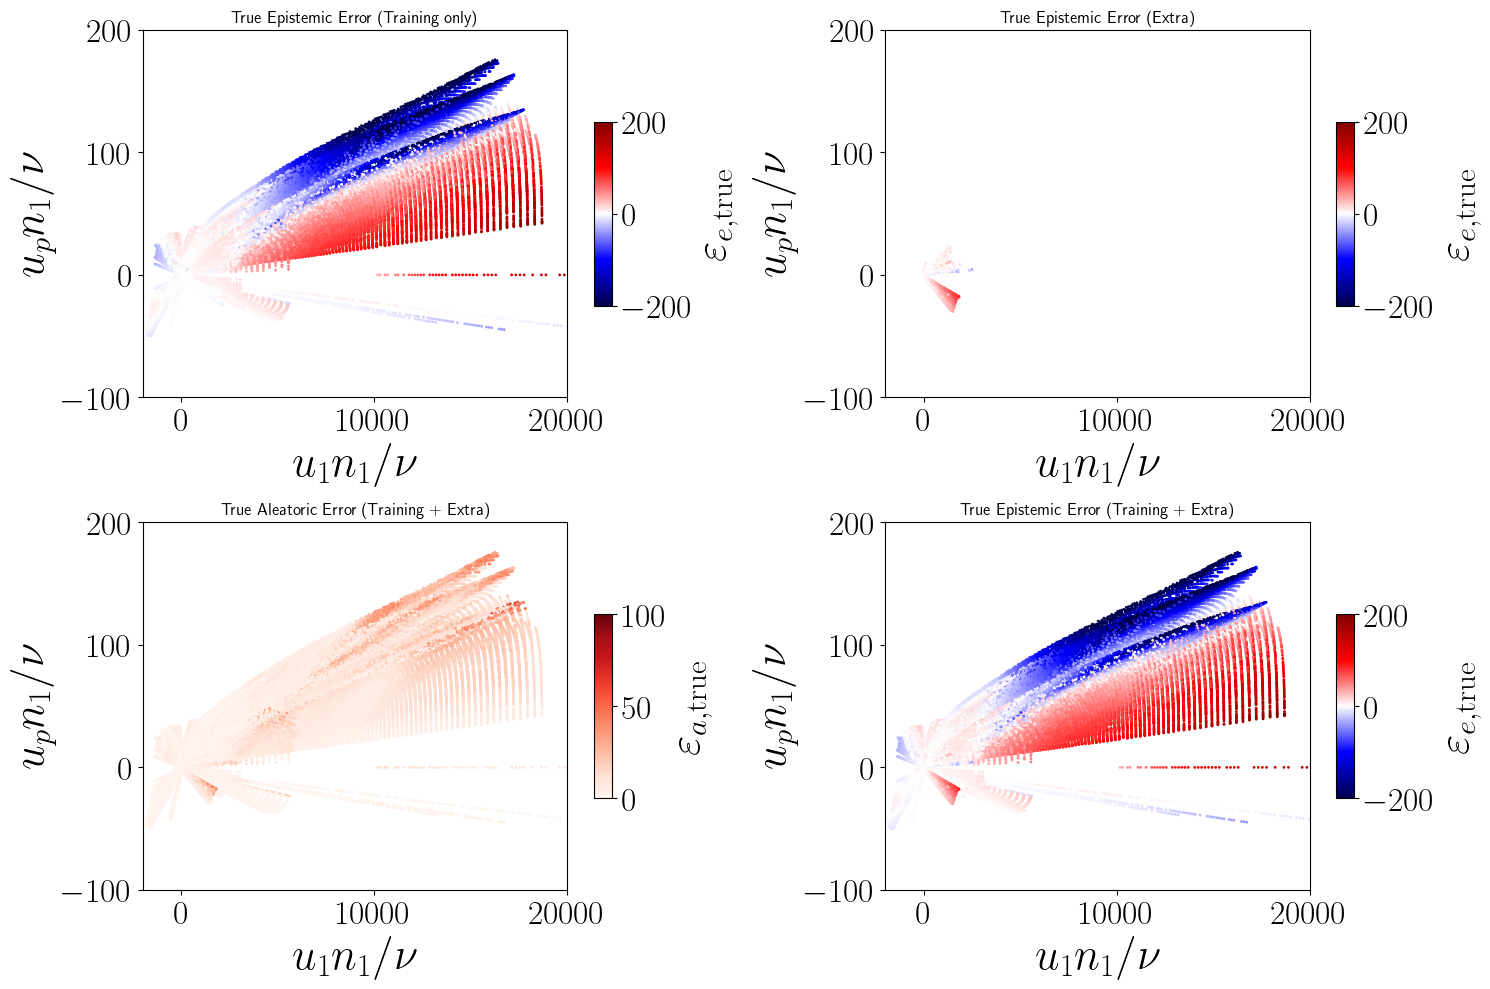

In [16]:
#Absolute errors
fig, ax = plt.subplots(2,2, figsize=(15, 10))
sc0=ax[0,0].scatter(X_train[:,0], X_train[:,1], c=error_train,  cmap='seismic', s=1, alpha=1.0)
ax[0,0].set_title("True Epistemic Error (Training only)")
ax[0,0].set_xlabel(r"$u_1 n_1 / \nu$"); 
ax[0,0].set_ylabel(r"$u_p n_1 / \nu$")
fig.colorbar(sc0, ax=ax[0,0], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\varepsilon_{e, \rm{true}}$")
sc0.set_clim(-200, 200)
ax[0,0].set_xlim(-2000, 20000)
ax[0,0].set_ylim(-100, 200)

sc1=ax[0,1].scatter(X_extra_train[:,0], X_extra_train[:,1], c=error_extra_train,  cmap='seismic', s=1, alpha=1.0)
ax[0,1].set_title("True Epistemic Error (Extra)")
ax[0,1].set_xlabel(r"$u_1 n_1 / \nu$"); 
ax[0,1].set_ylabel(r"$u_p n_1 / \nu$")
fig.colorbar(sc1, ax=ax[0,1], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\varepsilon_{e, \rm{true}}$")
sc1.set_clim(-200, 200)
ax[0,1].set_xlim(-2000, 20000)
ax[0,1].set_ylim(-100, 200)

sc2=ax[1,1].scatter(X_error_train[:,0], X_error_train[:,1], c=error_train_combined,  cmap='seismic', s=1, alpha=1.0)
ax[1,1].set_title("True Epistemic Error (Training + Extra)")
ax[1,1].set_xlabel(r"$u_1 n_1 / \nu$"); 
ax[1,1].set_ylabel(r"$u_p n_1 / \nu$")
fig.colorbar(sc2, ax=ax[1,1], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\varepsilon_{e, \rm{true}}$")
sc2.set_clim(-200, 200)
ax[1,1].set_xlim(-2000, 20000)
ax[1,1].set_ylim(-100, 200)

sc3=ax[1,0].scatter(X_error_train[:,0], X_error_train[:,1], c=sigma_knn,  cmap='Reds', s=1, alpha=1.0)
ax[1,0].set_title("True Aleatoric Error (Training + Extra)")
ax[1,0].set_xlabel(r"$u_1 n_1 / \nu$"); 
ax[1,0].set_ylabel(r"$u_p n_1 / \nu$")
fig.colorbar(sc3, ax=ax[1,0], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\varepsilon_{a, \rm{true}}$")
sc3.set_clim(0, 100)
ax[1,0].set_xlim(-2000, 20000)
ax[1,0].set_ylim(-100, 200)

plt.tight_layout()
plt.show()

In [17]:
# fig, ax = plt.subplots(2,2, figsize=(15, 10))
# sc0=ax[0,0].scatter(X_train[:,0], X_train[:,1], c=error_orig_train_perc,  cmap='seismic', s=1, alpha=1.0)
# ax[0,0].set_title("True Error (Training only)")
# ax[0,0].set_xlabel(r"$u_1 n_1 / \nu$"); 
# ax[0,0].set_ylabel(r"$u_p n_1 / \nu$")
# fig.colorbar(sc0, ax=ax[0,0], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\% ~ \varepsilon_{e, \rm{true}}$")
# sc0.set_clim(-100, 100)
# ax[0,0].set_xlim(-2000, 20000)
# ax[0,0].set_ylim(-100, 200)

# sc1=ax[0,1].scatter(X_extra[:,0], X_extra[:,1], c=error_extra_perc,  cmap='seismic', s=1, alpha=1.0)
# ax[0,1].set_title("True Error (Extra)")
# ax[0,1].set_xlabel(r"$u_1 n_1 / \nu$"); 
# ax[0,1].set_ylabel(r"$u_p n_1 / \nu$")
# fig.colorbar(sc1, ax=ax[0,1], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\% ~ \varepsilon_{e, \rm{true}}$")
# sc1.set_clim(-100, 100)
# ax[0,1].set_xlim(-2000, 20000)
# ax[0,1].set_ylim(-100, 200)

# sc2=ax[1,0].scatter(X_error_train[:,0], X_error_train[:,1], c=error_train_perc,  cmap='seismic', s=1, alpha=1.0)
# ax[1,0].set_title("True Error (Training + Extra)")
# ax[1,0].set_xlabel(r"$u_1 n_1 / \nu$"); 
# ax[1,0].set_ylabel(r"$u_p n_1 / \nu$")
# fig.colorbar(sc2, ax=ax[1,0], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\% ~ \varepsilon_{e, \rm{true}}$")
# sc2.set_clim(-100, 100)
# ax[1,0].set_xlim(-2000, 20000)
# ax[1,0].set_ylim(-100, 200)

# sc3=ax[1,1].scatter(X_test_all[:,0], X_test_all[:,1], c=error_test_perc,  cmap='seismic', s=1, alpha=1.0)
# ax[1,1].set_title("True Error (Test)")
# ax[1,1].set_xlabel(r"$u_1 n_1 / \nu$"); 
# ax[1,1].set_ylabel(r"$u_p n_1 / \nu$")
# fig.colorbar(sc3, ax=ax[1,1], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\% ~ \varepsilon_{e, \rm{true}}$")
# sc3.set_clim(-100, 100)
# ax[1,1].set_xlim(-2000, 20000)
# ax[1,1].set_ylim(-100, 200)

# plt.tight_layout()
# plt.show()

In [18]:
# # plot x and y coordinates to visualize where in the domain errors are high
# xcoord_test = np.array([float(flow_type_test_all[i, 2]) for i in range(len(flow_type_test_all))])
# ydelta_test = unnormalized_inputs_test_all[:,0]/np.array([float(flow_type_test_all[i, 3]) for i in range(len(flow_type_test_all))])

# fig, ax = plt.subplots(2,1, figsize=(8, 10))

# sc0=ax[0].scatter(X_test_all[:,0], X_test_all[:,1], c=xcoord_test,  cmap='jet', s=1, alpha=1.0)
# ax[0].set_title("Streamwise coordinate")
# ax[0].set_xlabel(r"$u_1 n_1 / \nu$"); 
# ax[0].set_ylabel(r"$u_p n_1 / \nu$")
# fig.colorbar(sc0, ax=ax[0], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$x$")
# sc0.set_clim(0, np.max(xcoord_test))
# ax[0].set_xlim(-2000, 20000)
# # ax[0].set_ylim(-100, 200)

# sc1=ax[1].scatter(X_test_all[:,0], X_test_all[:,1], c=ydelta_test,  cmap='jet', s=1, alpha=1.0)
# ax[1].set_title("Wall-normal coordinate")
# ax[1].set_xlabel(r"$u_1 n_1 / \nu$"); 
# ax[1].set_ylabel(r"$u_p n_1 / \nu$")
# fig.colorbar(sc1, ax=ax[1], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$n_1/\delta$")
# sc1.set_clim(0,  np.max(ydelta_test))
# ax[1].set_xlim(-2000, 20000)
# # ax[1].set_ylim(-100, 200)

# plt.tight_layout()
# plt.show()

In [19]:
# # --- BNN (with modified kl weight) Error Model using TFP ---

# from tensorflow.keras.models import load_model          # Load the saved error model
# import tensorflow_probability as tfp
# tfd = tfp.distributions

# # define weigh of kl divergence to be small so that BNN focuses more on mean rather than std
# kl_weight = 1e-4
# def small_kl(q, p, _):
#     return kl_weight * tfp.distributions.kl_divergence(q, p)

# # Use same architecture as the baseline model but with dual output
# def build_dual_output_nll_model(input_dim, config):
#     hidden_layers = config['model'].get('HiddenLayers', [64, 64])  # fallback if not specified

#     model = tf.keras.Sequential()
#     model.add(tf.keras.layers.InputLayer(input_shape=(input_dim,)))
    
#     for units in hidden_layers:
#         model.add(tfp.layers.DenseReparameterization(units, activation='relu', kernel_divergence_fn=small_kl))
    
#     # Final dense layer outputs [mu, log_sigma]
#     model.add(tfp.layers.DenseReparameterization(2, kernel_divergence_fn=small_kl))
#     model.add(tfp.layers.DistributionLambda(
#         make_distribution_fn=lambda t: tfd.Normal(
#             loc=t[..., :1],
#             scale=1e-3 + tf.nn.softplus(0.5 * t[..., 1:])  # σ = softplus(logσ²/2)
#         )
#     ))
    
#     return model

# def nll_loss(y_true, y_pred):
#     return -y_pred.log_prob(y_true)

# if train_err_model_flag:
#     print("Initializing Error Model...")
#     with tf.device(device_name):
#         error_model = build_dual_output_nll_model(X_train.shape[1], config_loaded_model)
#         error_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=nll_loss)
# else:
#     # Load the pre-trained error model
#     print("Loading Error Model...")
#     error_model = load_model(error_model_save_path, custom_objects={'DistributionLambda': tfp.layers.DistributionLambda, 'nll_loss': nll_loss, 'Normal': tfd.Normal})
#     error_model.summary()


In [16]:
# --- Error Model: Dual-output NLL Regression ---
from tensorflow.keras.models import load_model          # Load the saved error model
import tensorflow_probability as tfp
tfd = tfp.distributions

# Use same architecture as the baseline model but with dual output
def build_dual_output_nll_model(input_dim, config):
    hidden_layers = config['model'].get('HiddenLayers', [64, 64])  # fallback if not specified

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(input_dim,)))
    
    for units in hidden_layers:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    
    # Final dense layer outputs [mu, log_sigma]
    model.add(tf.keras.layers.Dense(2))
    model.add(tfp.layers.DistributionLambda(
        make_distribution_fn=lambda t: tfd.Normal(
            loc=t[..., :1],
            scale=1e-3 + tf.nn.softplus(t[..., 1:])
        )
    ))
    
    return model

def nll_loss(y_true, y_pred):
    return -y_pred.log_prob(y_true)

if train_err_model_flag:
    if hierarchy_flag:
        print("Not initializing Hierarchy Error Model here, since hierarchy models are initialized inside its own function...")
    else:
        print("Initializing Error Model...")
        with tf.device(device_name):
            error_model = build_dual_output_nll_model(X_train.shape[1], config_loaded_model)
            error_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=nll_loss)
else:
    # Load the pre-trained error model
    if hierarchy_flag:
        print("Loading Hierarchy Error Model...")
        error_models = []
        norm_stats = []
        for i in range(n_stages):
            model_path = error_model_save_path + f'_{i+1}'
            normstats_path = error_model_save_path + f'_{i+1}_normstats.pkl'
            loaded_model = load_model(model_path, custom_objects={'DistributionLambda': tfp.layers.DistributionLambda, 'nll_loss': nll_loss, 'Normal': tfd.Normal})
            loaded_model.summary()
            error_models.append(loaded_model)
            with open(normstats_path, 'rb') as f:
                norm_stats.append(pickle.load(f))
    else:
        print("Loading Error Model...")
        error_model = load_model(error_model_save_path, custom_objects={'DistributionLambda': tfp.layers.DistributionLambda, 'nll_loss': nll_loss, 'Normal': tfd.Normal})
        error_model.summary()

Not initializing Hierarchy Error Model here, since hierarchy models are initialized inside its own function...


In [17]:
# WEIGHTED TRAINING

# --- Parameters ---
weight_err_threshold = 10   # define error threshold (absolute value, not a percentage)
low_err_weight = 0.1          # downweight samples with very low error
extra_sample_weight_factor = 1.0   # weight for X_extra samples (adjust)

# Build label array (dummy label for extra samples)
labels_error_train = np.concatenate([
    labels_train,  # For X_train
    np.full(len(X_extra_train), -1)  # For X_extra
])

#IH: 
# NOTE: Weighting by inverse class frequency might result in assigning low weights to sparse regions of TBL_5-20 
#       (overall many samples but still sparse in top right region of u1 vs up plot)

# Compute per-class weights from training set
class_weight_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_train),
    y=labels_train
)
class_weights = {i: w for i, w in enumerate(class_weight_array)}


# Assign weights
sample_weights = np.ones(len(error_train_combined))

for i, label in enumerate(labels_error_train):
    if label != -1:
        sample_weights[i] = sample_weights[i]
        # Weighted by inverse class frequency
        sample_weights[i] = class_weights.get(label, 1.0)
    else:
        # Assign higher weight to test-derived samples
        sample_weights[i] *= extra_sample_weight_factor

# Downweight low-error samples
abs_errors = np.abs(error_train_combined)
low_error_indices = abs_errors < weight_err_threshold
sample_weights[low_error_indices] *= low_err_weight

# Print percentage of low_error_indices
print("Percentage of low-error samples:", np.mean(low_error_indices) * 100, "%")

# Print max and min weights
print("Sample Weights - Max:", np.max(sample_weights), "Min:", np.min(sample_weights))

Percentage of low-error samples: 93.1958426589585 %
Sample Weights - Max: 112.44034188034188 Min: 0.029981877121780638


In [18]:
# Import Hierarchical Error Model Functions
from hierarchical_error_model import hierarchical_error_correction, hierarchical_error_inference

In [20]:
# Train error model only on combined dataset, with validation data

# Set learning rate schedule for error model
error_lr_schedule = tf.keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=2e-3,
    decay_steps=epochs,
    end_learning_rate=1e-4,
    power=1.0,
    cycle=False
)

if train_err_model_flag:
    if hierarchy_flag:
        print("Training Hierarchy Error Model...")
        if weight_flag:
            error_models, norm_stats, y_pred_hier, error_pred_hier, error_pred_std_hier = hierarchical_error_correction(
                X_error_train,                # Training inputs
                y_error_train,                # True outputs
                y_error_train_pred,           # Initial predictions (from baseline model)
                X_error_valid,                # Validation inputs
                y_error_valid,                # True validation outputs
                y_error_valid_pred,           # Initial validation predictions
                config_loaded_model,          # Model config
                device_name,                  # Device string (e.g., '/GPU:0')
                epoch_hier,                   # Number of epochs per stage
                error_lr_schedule,            # Learning rate schedule
                n_stages=n_stages,            # Number of hierarchy stages
                sample_weights=sample_weights # Optional sample weights
            )
        else:
            error_models, norm_stats, y_pred_hier, error_pred_hier, error_pred_std_hier = hierarchical_error_correction(
                X_error_train,                # Training inputs
                y_error_train,                # True outputs
                y_error_train_pred,           # Initial predictions (from baseline model)
                X_error_valid,                # Validation inputs
                y_error_valid,                # True validation outputs
                y_error_valid_pred,           # Initial validation predictions
                config_loaded_model,          # Model config
                device_name,                  # Device string (e.g., '/GPU:0')
                epoch_hier,                   # Number of epochs per stage
                error_lr_schedule,            # Learning rate schedule
                n_stages=n_stages             # Number of hierarchy stages
            )
        # Saving all error_models from hierarchical_error_correction
        if save_flag:
            for i, err_model in enumerate(error_models):
                # Save model
                err_model.save(error_model_save_path + f'_{i+1}')
                # Save norm_stats for each stage
                with open(error_model_save_path + f'_{i+1}_normstats.pkl', 'wb') as f:
                    pickle.dump(norm_stats[i], f)
                    
    else:
        print("Training Error Model...")
        # Fit the model on training data, with validation data
        if weight_flag:
            error_model.fit(X_error_train_norm, error_train_combined_norm, epochs=epochs, batch_size=50000, callbacks=[tf.keras.callbacks.LearningRateScheduler(error_lr_schedule)], verbose=1, sample_weight=sample_weights,
                validation_data=(X_error_valid_norm, error_valid_combined_norm))
        else:
            error_model.fit(X_error_train_norm, error_train_combined_norm, epochs=epochs, batch_size=50000, callbacks=[tf.keras.callbacks.LearningRateScheduler(error_lr_schedule)], verbose=1,
                validation_data=(X_error_valid_norm, error_valid_combined_norm))
        # Save the trained model
        if save_flag:
            error_model.save(error_model_save_path)
            print(f"Error model saved to {error_model_save_path}")

else:
    print("No Training: Error model already loaded from", error_model_save_path)

Training Hierarchy Error Model...

--- Training Error Model Stage 1 ---
Epoch 1/10
14/14 [==============================] - 2s 21ms/step - loss: 30175.7109 - val_loss: 0.5065 - lr: 0.0020
Epoch 2/10
14/14 [==============================] - 0s 7ms/step - loss: 0.9076 - val_loss: 0.0745 - lr: 0.0018
Epoch 3/10
14/14 [==============================] - 0s 8ms/step - loss: 0.5176 - val_loss: -0.1543 - lr: 0.0016
Epoch 4/10
14/14 [==============================] - 0s 9ms/step - loss: 0.3393 - val_loss: -0.6620 - lr: 0.0014
Epoch 5/10
14/14 [==============================] - 0s 7ms/step - loss: 0.2147 - val_loss: -1.2430 - lr: 0.0012
Epoch 6/10
14/14 [==============================] - 0s 8ms/step - loss: 0.1361 - val_loss: -1.5406 - lr: 0.0011
Epoch 7/10
14/14 [==============================] - 0s 8ms/step - loss: 0.0915 - val_loss: -1.7200 - lr: 8.6000e-04
Epoch 8/10
14/14 [==============================] - 0s 8ms/step - loss: 0.0642 - val_loss: -1.7845 - lr: 6.7000e-04
Epoch 9/10
14/14 [===

INFO:tensorflow:Assets written to: ./models/error_model_Baseline_wGaussian_Add_SpinD_Trans_CurvedTBL_weight_wVal_ep10_hierarchy_1/assets


INFO:tensorflow:Assets written to: ./models/error_model_Baseline_wGaussian_Add_SpinD_Trans_CurvedTBL_weight_wVal_ep10_hierarchy_2/assets


INFO:tensorflow:Assets written to: ./models/error_model_Baseline_wGaussian_Add_SpinD_Trans_CurvedTBL_weight_wVal_ep10_hierarchy_2/assets


In [ ]:
# --- Plot loss vs epoch for error model if trained above ---
if train_err_model_flag:
    plt.figure(figsize=(10, 5))
    plt.plot(error_model.history.history['loss'], label='Train Loss')
    if 'val_loss' in error_model.history.history:
        plt.plot(error_model.history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Error Model Training Loss')
    plt.ylim(-6,1)
    # plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# Predict error distribution on test set
error_pred_train_norm = error_model(X_error_train_norm)

# mean and stddev are attributes of distribution, so do this before multiplying and adding std_train and mean_train
error_pred_mean_train = error_pred_train_norm.mean().numpy().flatten()     
error_pred_std_train = error_pred_train_norm.stddev().numpy().flatten()

# Rescale
error_pred_mean_train = error_pred_mean_train * std_error_train + mean_error_train  # Rescale to original error scale
error_pred_std_train  = error_pred_std_train  * std_error_train  # Rescale to original

# Predict error distribution on test set
error_pred_test_norm = error_model(X_test_norm)
error_pred_mean_test = error_pred_test_norm.mean().numpy().flatten()
error_pred_std_test  = error_pred_test_norm.stddev().numpy().flatten()

error_pred_mean_test = error_pred_mean_test * std_error_train + mean_error_train  # Rescale to original error scale
error_pred_std_test  = error_pred_std_test  * std_error_train  # Rescale to original

In [22]:
# Calculate percentage error_pred_mean_train and error_pred_std_train
error_pred_mean_train_perc = (error_pred_mean_train / y_error_train) * 100
error_pred_std_train_perc  = (error_pred_std_train  / y_error_train) * 100

# Calculate percentage error_pred_mean_test and error_pred_std_test
error_pred_mean_test_perc = (error_pred_mean_test / y_test_all) * 100
error_pred_std_test_perc  = (error_pred_std_test  / y_test_all) * 100

/tmp/ipykernel_981596/3215726909.py:2: RuntimeWarning: divide by zero encountered in divide
  error_pred_mean_train_perc = (error_pred_mean_train / y_error_train) * 100
/tmp/ipykernel_981596/3215726909.py:3: RuntimeWarning: divide by zero encountered in divide
  error_pred_std_train_perc  = (error_pred_std_train  / y_error_train) * 100
/tmp/ipykernel_981596/3215726909.py:6: RuntimeWarning: divide by zero encountered in divide
  error_pred_mean_test_perc = (error_pred_mean_test / y_test_all) * 100
/tmp/ipykernel_981596/3215726909.py:7: RuntimeWarning: divide by zero encountered in divide
  error_pred_std_test_perc  = (error_pred_std_test  / y_test_all) * 100


In [24]:
def plot_error_distribution_perc(X_baseline, X_extra, X_test, error_test_perc,  error_pred_mean_test_perc, error_pred_std_test_perc):

    fig, ax = plt.subplots(2,2, figsize=(15, 10))
    ax[0,0].scatter(X_baseline[:,0], X_baseline[:,1], color='blue', s=1.5, alpha=1.0, label='Baseline Data')
    ax[0,0].scatter(X_extra[:,0], X_extra[:,1],       color='red',  s=0.1, alpha=1.0, label='Additional Data')
    ax[0,0].set_title("Baseline and Additional Data for Error Model")
    ax[0,0].set_xlabel(r"$u_1 n_1 / \nu$"); ax[0,0].set_ylabel(r"$u_p n_1 / \nu$")
    ax[0,0].legend(loc='upper right', fontsize=12)

    sc1=ax[0,1].scatter(X_test[:,0], X_test[:,1], c=error_test_perc,  cmap='seismic', s=1, alpha=1.0)
    ax[0,1].set_title("True Error")
    ax[0,1].set_xlabel(r"$u_1 n_1 / \nu$"); ax[0,0].set_ylabel(r"$u_p n_1 / \nu$")
    fig.colorbar(sc1, ax=ax[0,1], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\% ~ \varepsilon_{e, \rm{true}}$")
    sc1.set_clim(-100, 100)

    sc2=ax[1,1].scatter(X_test[:,0], X_test[:,1], c=error_pred_mean_test_perc, cmap='seismic', s=1, alpha=1.0)
    ax[1,1].set_title("Predicted Epistemic error")
    ax[1,1].set_xlabel(r"$u_1 n_1 / \nu$"); ax[1,1].set_ylabel(r"$u_p n_1 / \nu$")
    fig.colorbar(sc2, ax=ax[1,1], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\% ~ \varepsilon_{e}$")
    sc2.set_clim(-100, 100)

    sc3=ax[1,0].scatter(X_test[:,0], X_test[:,1], c=error_pred_std_test_perc, cmap='Reds', s=1, alpha=1.0)
    ax[1,0].set_title("Predicted Aleatoric error")
    ax[1,0].set_xlabel(r"$u_1 n_1 / \nu$"); ax[1,0].set_ylabel(r"$u_p n_1 / \nu$")
    fig.colorbar(sc3, ax=ax[1,0], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\% ~ \varepsilon_{a}$")
    sc3.set_clim(0, 50)

    ax[0,0].set_xlim(-2000, 20000)
    ax[0,1].set_xlim(-2000, 20000)
    ax[1,0].set_xlim(-2000, 20000)
    ax[1,1].set_xlim(-2000, 20000)

    plt.tight_layout()
    plt.show()

def plot_error_distribution(X_baseline, X_extra, X_test, error_test,  error_pred_mean_test, error_pred_std_test):

    fig, ax = plt.subplots(2,2, figsize=(15, 10))
    ax[0,0].scatter(X_baseline[:,0], X_baseline[:,1], color='blue', s=1.5, alpha=1.0, label='Baseline Data')
    ax[0,0].scatter(X_extra[:,0], X_extra[:,1],       color='red',  s=2.0, alpha=1.0, label='Additional Data')
    ax[0,0].set_title("Baseline and Additional Data for Error Model")
    ax[0,0].set_xlabel(r"$u_1 n_1 / \nu$"); ax[0,0].set_ylabel(r"$u_p n_1 / \nu$")
    ax[0,0].legend(loc='upper right', fontsize=12)

    sc1=ax[0,1].scatter(X_test[:,0], X_test[:,1], c=error_test,  cmap='seismic', s=1, alpha=1.0)
    ax[0,1].set_title("True Error")
    ax[0,1].set_xlabel(r"$u_1 n_1 / \nu$"); ax[0,0].set_ylabel(r"$u_p n_1 / \nu$")
    fig.colorbar(sc1, ax=ax[0,1], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\varepsilon_{e, \rm{true}}$")
    sc1.set_clim(-200, 200)

    sc2=ax[1,1].scatter(X_test[:,0], X_test[:,1], c=error_pred_mean_test, cmap='seismic', s=1, alpha=1.0)
    ax[1,1].set_title("Predicted Epistemic error")
    ax[1,1].set_xlabel(r"$u_1 n_1 / \nu$"); ax[1,1].set_ylabel(r"$u_p n_1 / \nu$")
    fig.colorbar(sc2, ax=ax[1,1], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\varepsilon_{e}$")
    sc2.set_clim(-200, 200)

    sc3=ax[1,0].scatter(X_test[:,0], X_test[:,1], c=error_pred_std_test, cmap='Reds', s=1, alpha=1.0)
    ax[1,0].set_title("Predicted Aleatoric error")
    ax[1,0].set_xlabel(r"$u_1 n_1 / \nu$"); ax[1,0].set_ylabel(r"$u_p n_1 / \nu$")
    fig.colorbar(sc3, ax=ax[1,0], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\varepsilon_{a}$")
    sc3.set_clim(0, 100)

    ax[0,0].set_xlim(-2000, 20000)
    ax[0,1].set_xlim(-2000, 20000)
    ax[1,0].set_xlim(-2000, 20000)
    ax[1,1].set_xlim(-2000, 20000)

    plt.tight_layout()
    plt.show()

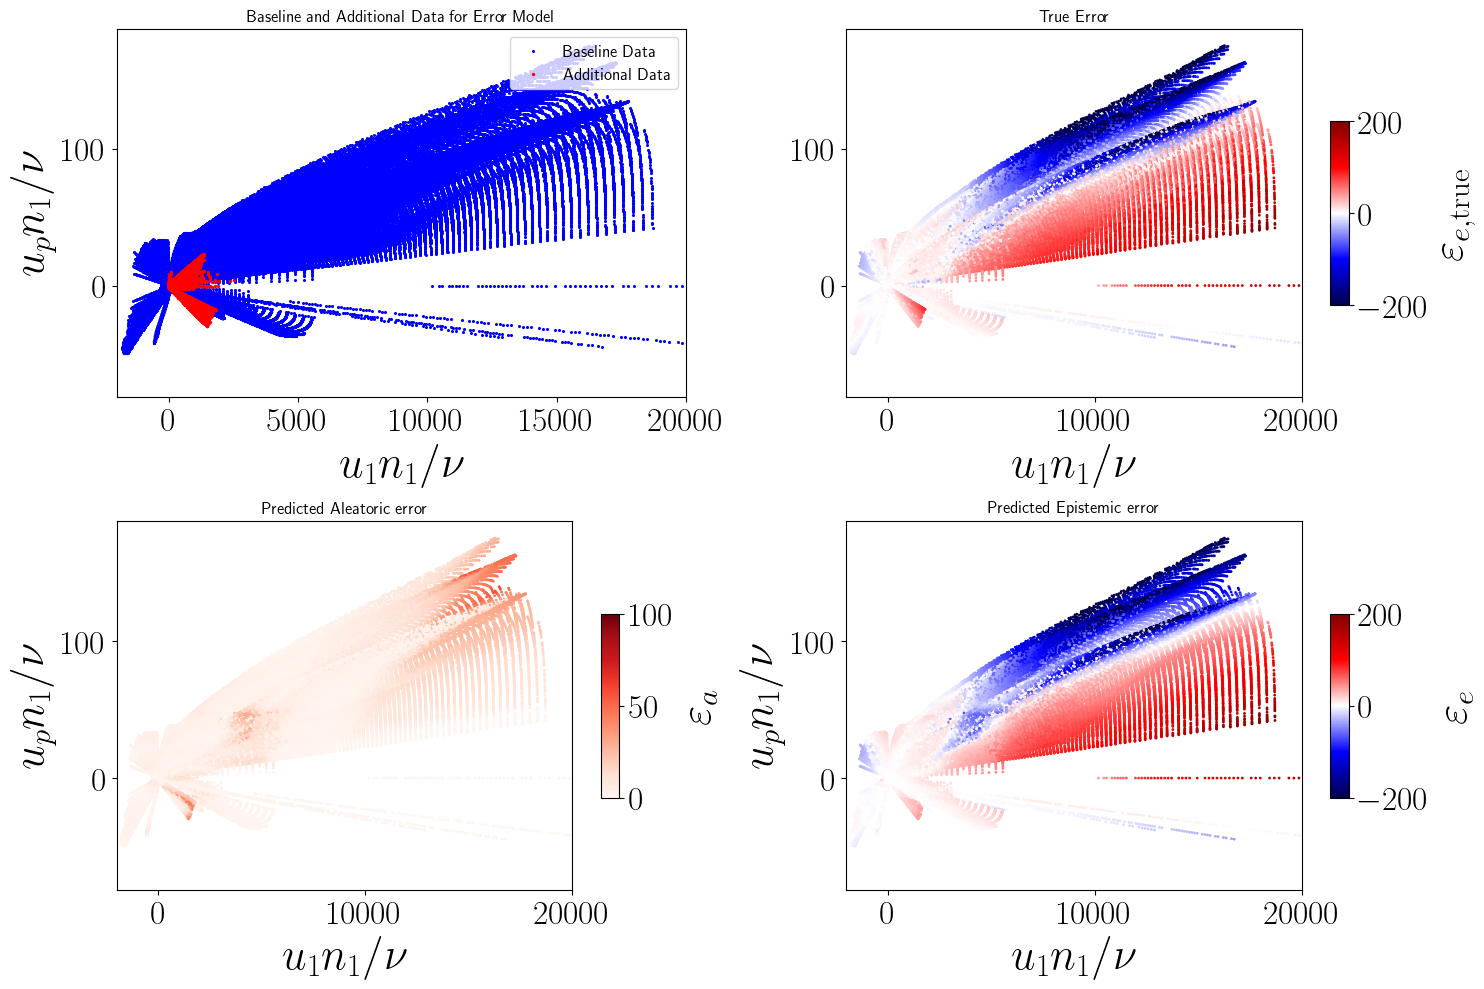

In [27]:
# Plot training data predictions
# plot_error_distribution_perc(X_train, X_extra, X_error_train, error_train_perc, error_pred_mean_train_perc, error_pred_std_train_perc)

# Absolute error
plot_error_distribution(X_train, X_extra, X_error_train, error_train_combined, error_pred_mean_train, error_pred_std_train)

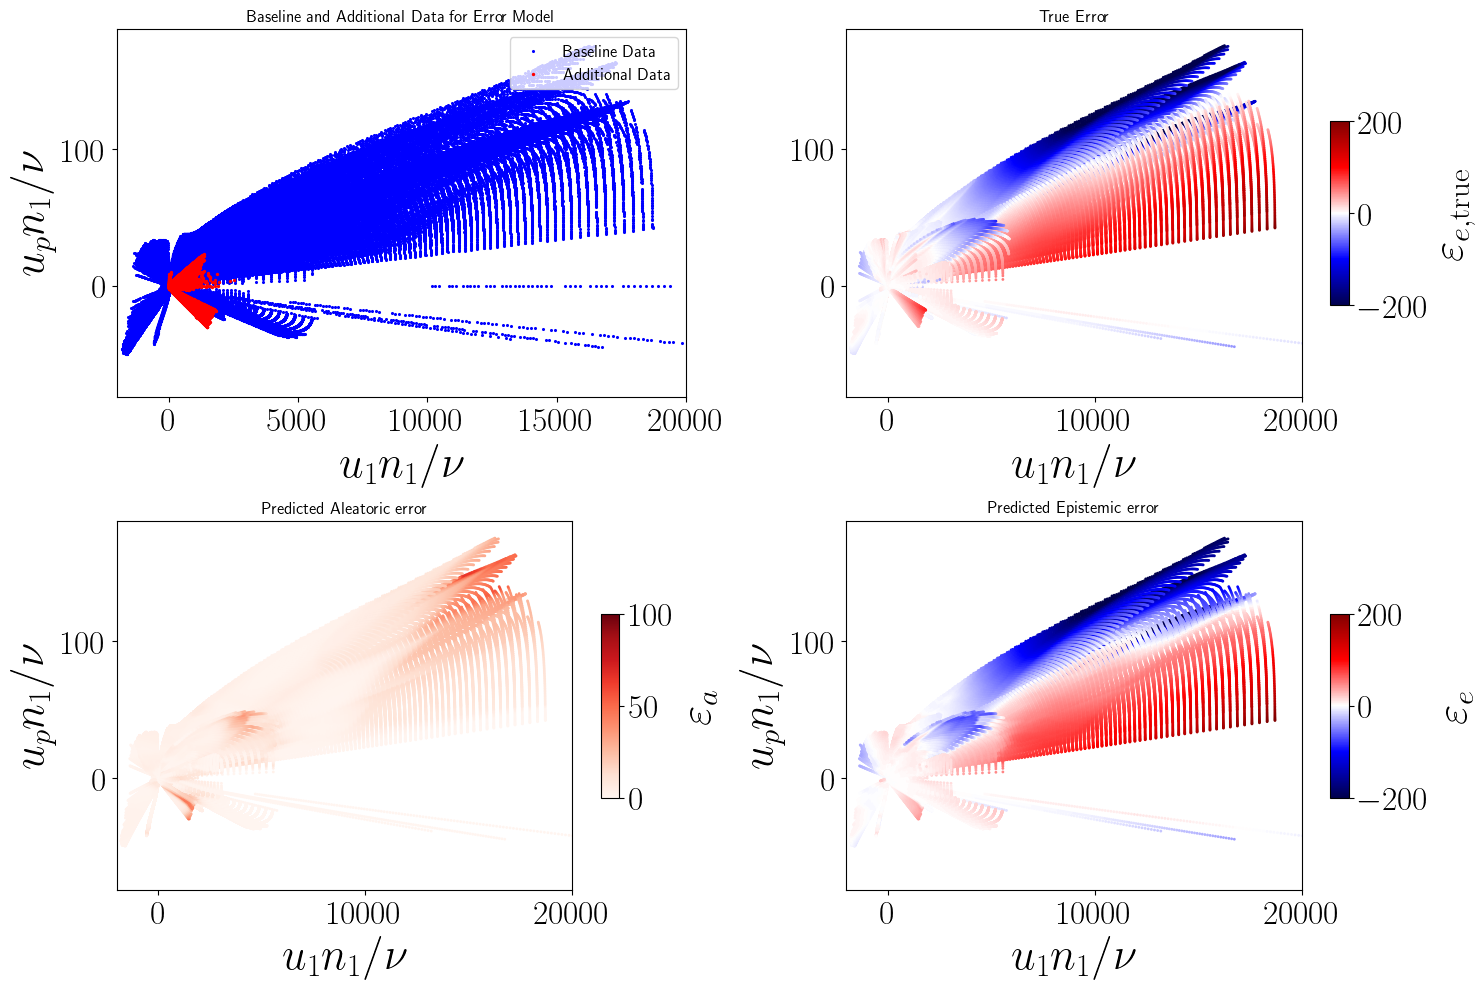

In [32]:
# # Plot test data predictions
# plot_error_distribution_perc(X_train, X_extra, X_test_all, error_test_perc, error_pred_mean_test_perc, error_pred_std_test_perc)

# Absolute error
plot_error_distribution(X_train, X_extra, X_test_all, error_test, error_pred_mean_test, error_pred_std_test)

/tmp/ipykernel_925143/4233458790.py:12: RuntimeWarning: divide by zero encountered in divide
  error_corrected_train_perc = (error_corrected_train / y_error_train) * 100
/tmp/ipykernel_925143/4233458790.py:13: RuntimeWarning: divide by zero encountered in divide
  error_corrected_test_perc  = (error_corrected_test  / y_test_all   ) * 100


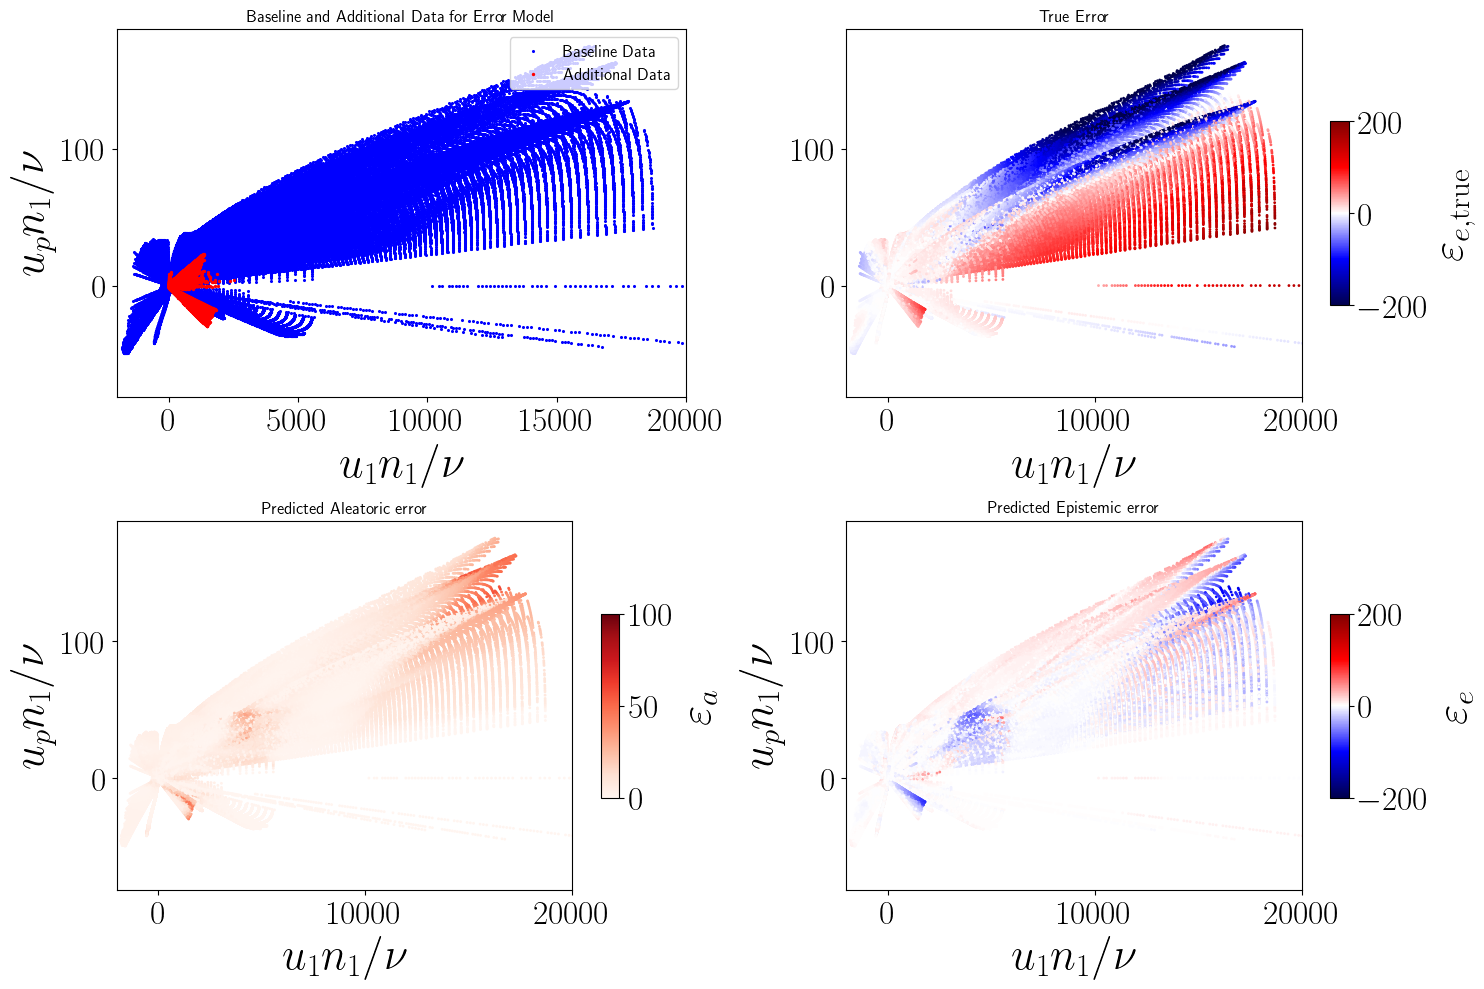

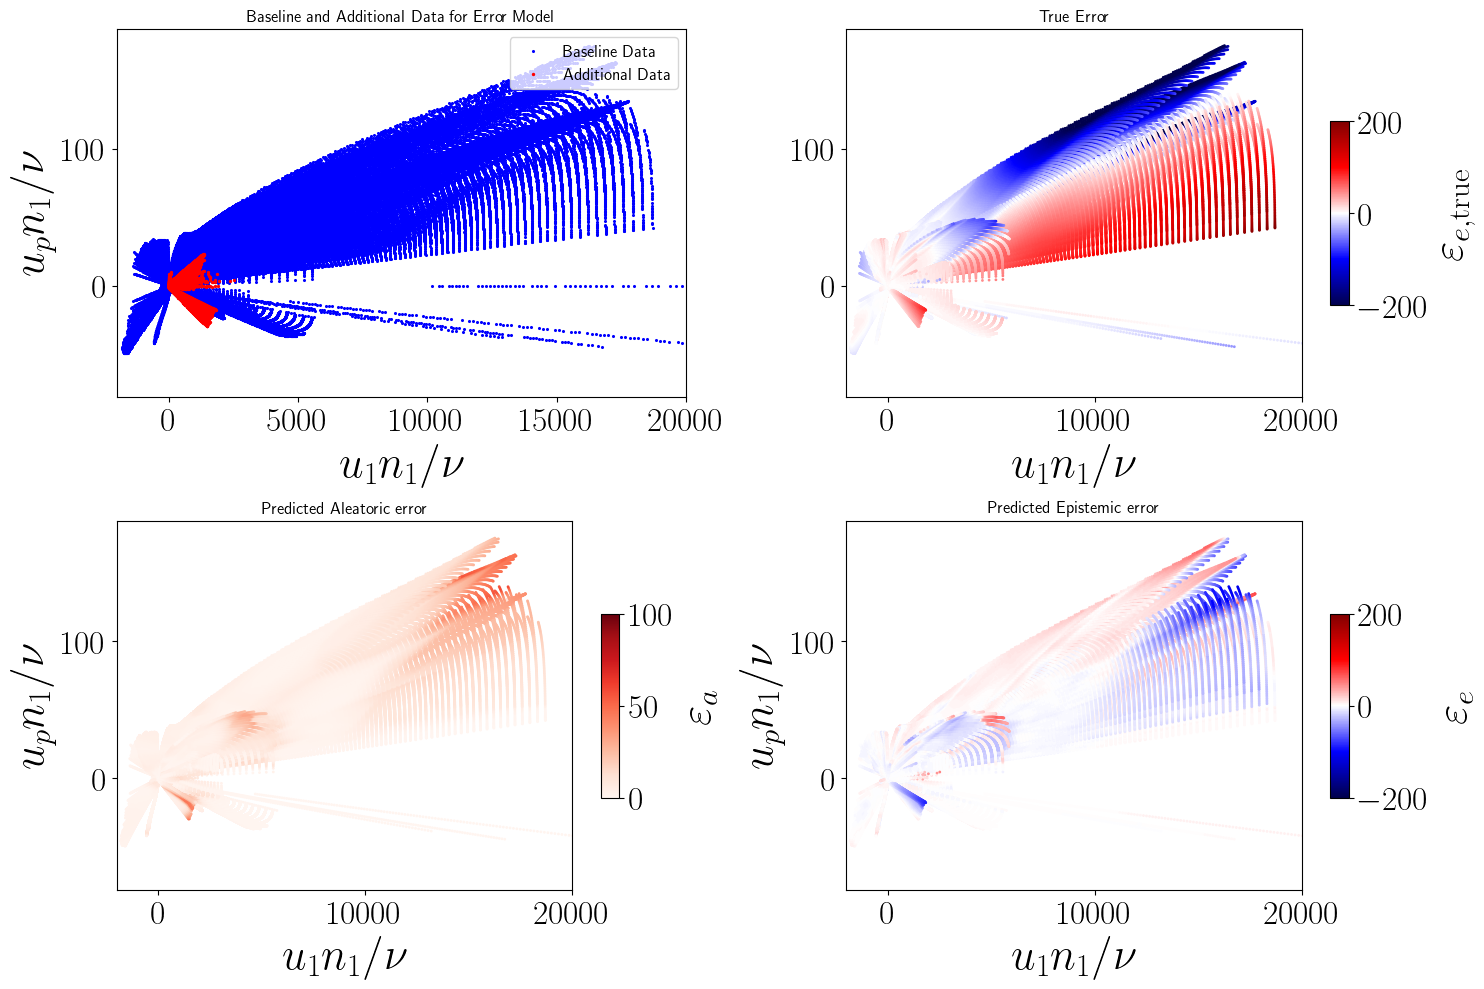

In [28]:
# CORRECTION TO BASELINE PRED

# Predict corrected train and test output
y_corrected_train = y_error_train_pred + error_pred_mean_train
y_corrected_test = y_pred_test + error_pred_mean_test

# Calculate abosulte error for corrected train and test output
error_corrected_train = y_corrected_train - y_error_train
error_corrected_test  = y_corrected_test  - y_test_all

# Calculate percentage error for corrected train and test output
error_corrected_train_perc = (error_corrected_train / y_error_train) * 100
error_corrected_test_perc  = (error_corrected_test  / y_test_all   ) * 100

# Plot corrected test data predictions
# plot_error_distribution_perc(X_train, X_extra, X_error_train, error_train_perc, error_corrected_train_perc, error_pred_std_train_perc)       #train
# plot_error_distribution_perc(X_train, X_extra, X_test_all, error_test_perc, error_corrected_test_perc, error_pred_std_test_perc)       #test

# Plot corrected test data (ABSOLUTE)
plot_error_distribution(X_train, X_extra, X_error_train, error_train_combined, error_corrected_train, error_pred_std_train)       #train
plot_error_distribution(X_train, X_extra, X_test_all,    error_test,           error_corrected_test,  error_pred_std_test)       #test

In [ ]:
# Example usage of hierarchical_error_inference
# error_models, norm_stats: outputs from hierarchical_error_correction
# X_test_all: test inputs
# y_pred_test: initial baseline predictions for test set

n_pred = 2  # Specify which stage's predictions to retrieve

y_pred_test_hier, error_pred_test_hier, error_pred_std_test_hier = hierarchical_error_inference(error_models, norm_stats, X_test_all, y_pred_test, n=n_pred)
# predict errors on train set if model was loaded
if not train_err_model_flag:
    y_pred_hier, error_pred_hier, error_pred_std_hier = hierarchical_error_inference(error_models, norm_stats, X_error_train, y_error_train_pred, n=n_pred)

# Calculate abosulte error for corrected train and test output
error_corrected_hier       = y_pred_hier       - y_error_train
error_corrected_test_hier  = y_pred_test_hier  - y_test_all

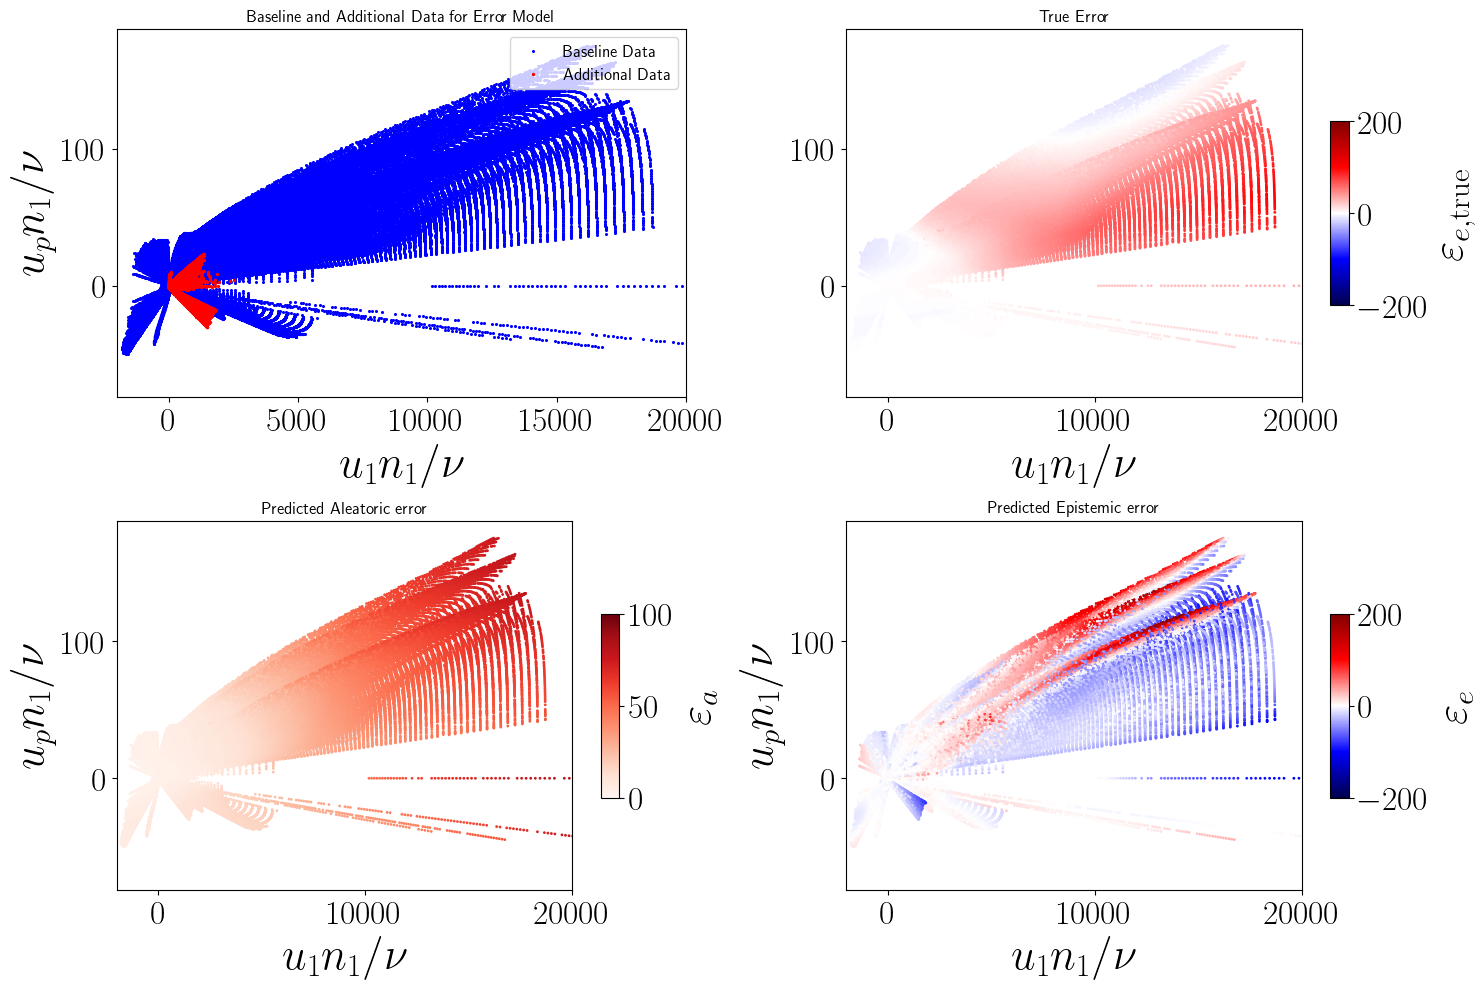

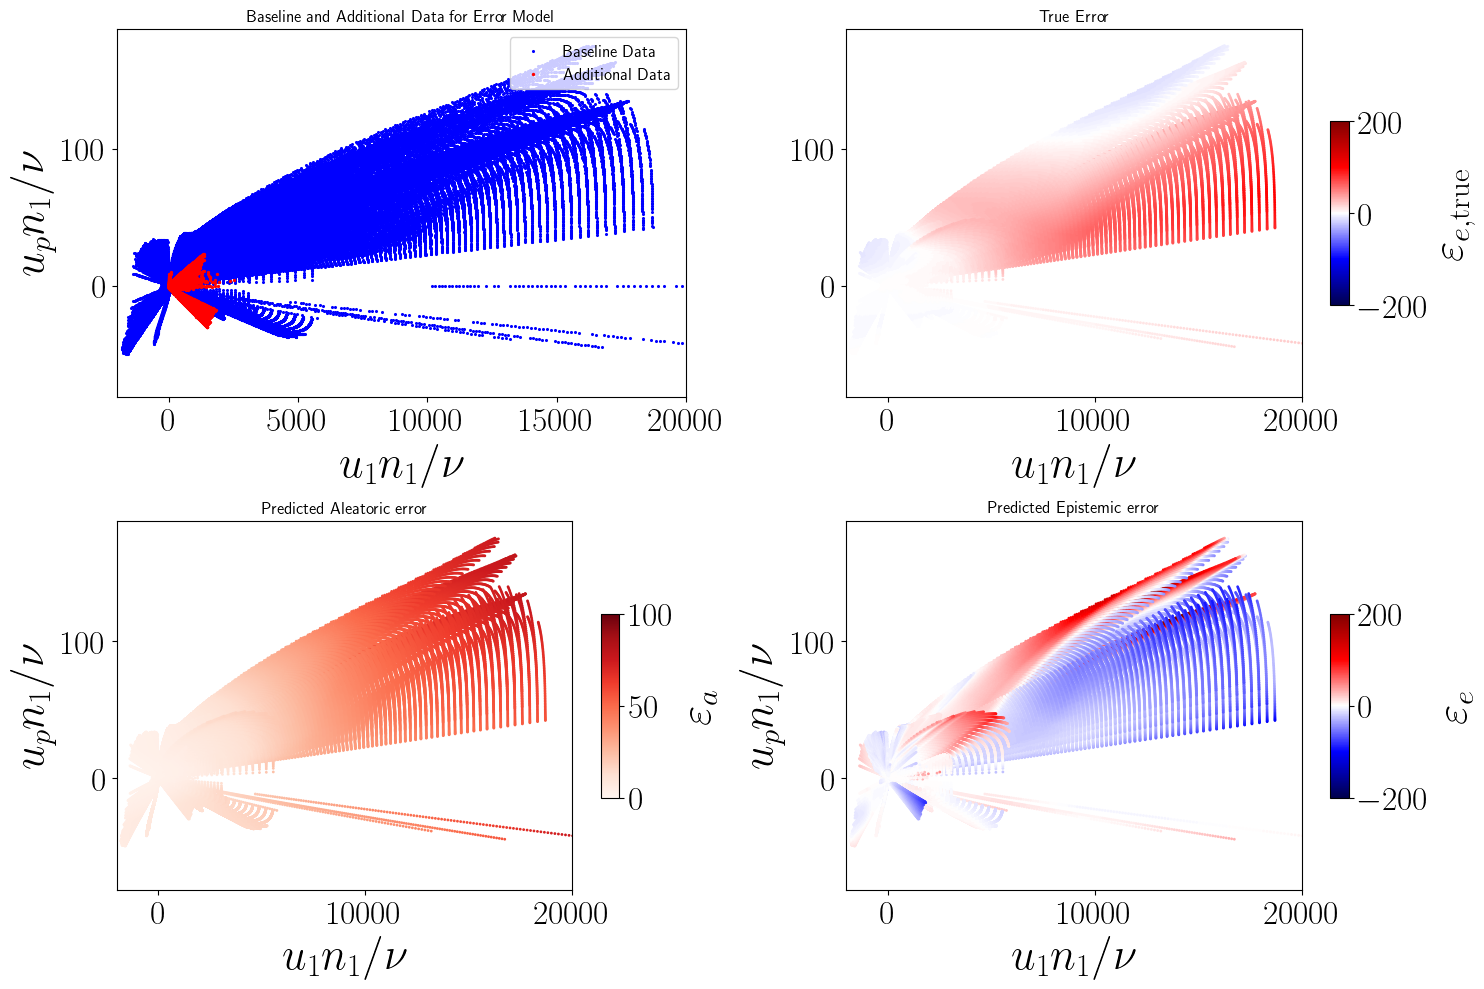

In [ ]:
# Plot corrected test data (ABSOLUTE)
plot_error_distribution(X_train, X_extra, X_error_train, error_pred_hier,      error_corrected_hier,       error_pred_std_hier     )       #train
plot_error_distribution(X_train, X_extra, X_test_all,    error_pred_test_hier, error_corrected_test_hier,  error_pred_std_test_hier)       #test

## Deselecting Noisy datapoints and retraining Error model

In [51]:
def split_by_aleatoric_error(X_error_train_norm, error_pred_std, error_train_combined_norm, y_error_train_pred, y_error_train, sample_weights, aleatoric_thresh):
    """
    Splits training data into two arrays based on predicted aleatoric error threshold.
    
    Parameters:
    -----------
    X_error_train_norm : numpy.ndarray
        Normalized input training data
    error_pred_std : numpy.ndarray
        Predicted standard deviation (aleatoric uncertainty)
    aleatoric_thresh : float
        Threshold value for splitting the data
        
    Returns:
    --------
    X_error_train_low : numpy.ndarray
        Training data with aleatoric error below threshold
    X_error_train_high : numpy.ndarray
        Training data with aleatoric error above threshold
    """
    
    # Create boolean mask for points below threshold
    low_ale_mask = error_pred_std <= aleatoric_thresh
    
    # Split data using the mask
    X_error_train_low  = X_error_train_norm[low_ale_mask]
    X_error_train_high = X_error_train_norm[~low_ale_mask]

    error_train_low  = error_train_combined_norm[low_ale_mask]
    error_train_high = error_train_combined_norm[~low_ale_mask]

    y_error_train_pred_low  = y_error_train_pred[low_ale_mask]
    y_error_train_pred_high = y_error_train_pred[~low_ale_mask]

    y_error_train_low  = y_error_train[low_ale_mask]
    y_error_train_high = y_error_train[~low_ale_mask]

    sample_weights_low  = sample_weights[low_ale_mask]
    sample_weights_high = sample_weights[~low_ale_mask]

    print(f"Original data points: {len(X_error_train_norm)}")
    print(f"Points with low aleatoric error: {len(X_error_train_low)}")
    print(f"Points with high aleatoric error: {len(X_error_train_high)}")

    return X_error_train_low, X_error_train_high, error_train_low, error_train_high, y_error_train_pred_low, y_error_train_pred_high, y_error_train_low, y_error_train_high, sample_weights_low, sample_weights_high

In [52]:
# Example usage
aleatoric_thresh = 40  # Set your desired threshold
X_error_train_low_norm, _, error_train_low_norm, _, y_error_train_pred_low, _, y_error_train_low, _, sample_weights_low, _ = split_by_aleatoric_error(X_error_train_norm, error_pred_std_train, error_train_combined_norm, y_error_train_pred, y_error_train, sample_weights, aleatoric_thresh)

Original data points: 665350
Points with low aleatoric error: 663675
Points with high aleatoric error: 1675


In [46]:
X_error_train_low = X_error_train_low_norm * std_X_error_train + mean_X_error_train  # Rescale to original input scale
error_train_low = error_train_low_norm * std_error_train + mean_error_train  # Rescale to original error scale

Retraining Error Model with Low Aleatoric Uncertainty Data...
Epoch 1/5000
14/14 [==============================] - 2s 3ms/step - loss: 0.3117 - lr: 0.0030
Epoch 2/5000
14/14 [==============================] - 0s 3ms/step - loss: -0.0901 - lr: 0.0030
Epoch 3/5000
14/14 [==============================] - 0s 3ms/step - loss: -1.0011 - lr: 0.0030
Epoch 4/5000
14/14 [==============================] - 0s 3ms/step - loss: -1.4677 - lr: 0.0030
Epoch 5/5000
14/14 [==============================] - 0s 3ms/step - loss: -1.7188 - lr: 0.0030
Epoch 6/5000
14/14 [==============================] - 0s 3ms/step - loss: -1.9032 - lr: 0.0030
Epoch 7/5000
14/14 [==============================] - 0s 3ms/step - loss: -1.8560 - lr: 0.0030
Epoch 8/5000
14/14 [==============================] - 0s 3ms/step - loss: -1.8349 - lr: 0.0030
Epoch 9/5000
14/14 [==============================] - 0s 3ms/step - loss: -2.1421 - lr: 0.0030
Epoch 10/5000
14/14 [==============================] - 0s 3ms/step - loss: -1.7253 -

INFO:tensorflow:Assets written to: ./models/error_model_low_ale_Baseline_wGaussian_Add_SpinD_Trans_CurvedTBL_Add10pcError_ep5000/assets


Error model saved to ./models/error_model_low_ale_Baseline_wGaussian_Add_SpinD_Trans_CurvedTBL_Add10pcError_ep5000


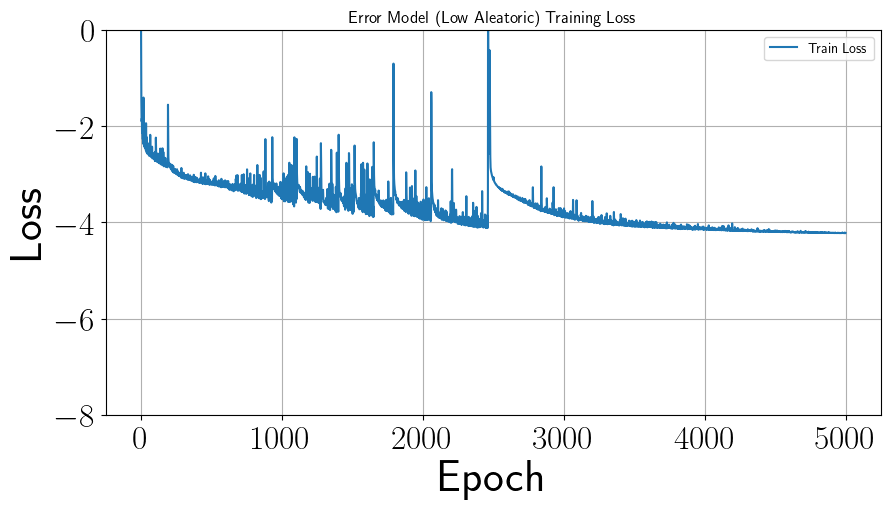

In [47]:
# --- Retrain error model with low aleatoric uncertainty data only ---
train_err_model_retrain_flag = 1  # User can set this to 0 to load existing model

# Path for saving/loading the retrained model
error_model_low_save_path = './models/error_model_low_ale_' + model_name

if train_err_model_retrain_flag:
    print("Retraining Error Model with Low Aleatoric Uncertainty Data...")
    
    # Initialize and compile new model
    with tf.device(device_name):
        error_model_low = build_dual_output_nll_model(X_train.shape[1], config_loaded_model)
        error_model_low.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=nll_loss)
    
    # Train model
    if weight_flag:
        history_low = error_model_low.fit(
            X_error_train_low_norm, 
            error_train_low_norm, 
            epochs=epochs, 
            batch_size=50000, 
            callbacks=[tf.keras.callbacks.LearningRateScheduler(error_lr_schedule)], 
            verbose=1, 
            sample_weight=sample_weights_low
        )
    else:
        history_low = error_model_low.fit(
            X_error_train_low_norm, 
            error_train_low_norm,
            epochs=epochs,
            batch_size=50000,
            callbacks=[tf.keras.callbacks.LearningRateScheduler(error_lr_schedule)],
            verbose=1
        )
    
    # Save the trained model
    error_model_low.save(error_model_low_save_path)
    print(f"Error model saved to {error_model_low_save_path}")

else:
    # Load the pre-trained error model
    print("Loading Error Model...")
    error_model_low = load_model(
        error_model_low_save_path, 
        custom_objects={
            'DistributionLambda': tfp.layers.DistributionLambda,
            'nll_loss': nll_loss,
            'Normal': tfd.Normal
        }
    )
    error_model_low.summary()

# Plot training loss if model was retrained
if train_err_model_retrain_flag:
    plt.figure(figsize=(10, 5))
    plt.plot(history_low.history['loss'], label='Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Error Model (Low Aleatoric) Training Loss')
    plt.ylim(-8,0)
    plt.legend()
    plt.grid(True)
    plt.show()

In [48]:
# Predict error distribution on test set
error_pred_train_low_norm = error_model_low(X_error_train_low_norm)

# mean and stddev are attributes of distribution, so do this before multiplying and adding std_train and mean_train
error_pred_mean_train_low = error_pred_train_low_norm.mean().numpy().flatten()     
error_pred_std_train_low = error_pred_train_low_norm.stddev().numpy().flatten()

# Rescale
error_pred_mean_train_low = error_pred_mean_train_low * std_error_train + mean_error_train  # Rescale to original error scale
error_pred_std_train_low  = error_pred_std_train_low  * std_error_train  # Rescale to original

# Predict error distribution on test set
error_pred_test_low_norm = error_model_low(X_test_norm)
error_pred_mean_test_low = error_pred_test_low_norm.mean().numpy().flatten()
error_pred_std_test_low  = error_pred_test_low_norm.stddev().numpy().flatten()

error_pred_mean_test_low = error_pred_mean_test_low * std_error_train + mean_error_train  # Rescale to original error scale
error_pred_std_test_low  = error_pred_std_test_low  * std_error_train  # Rescale to original

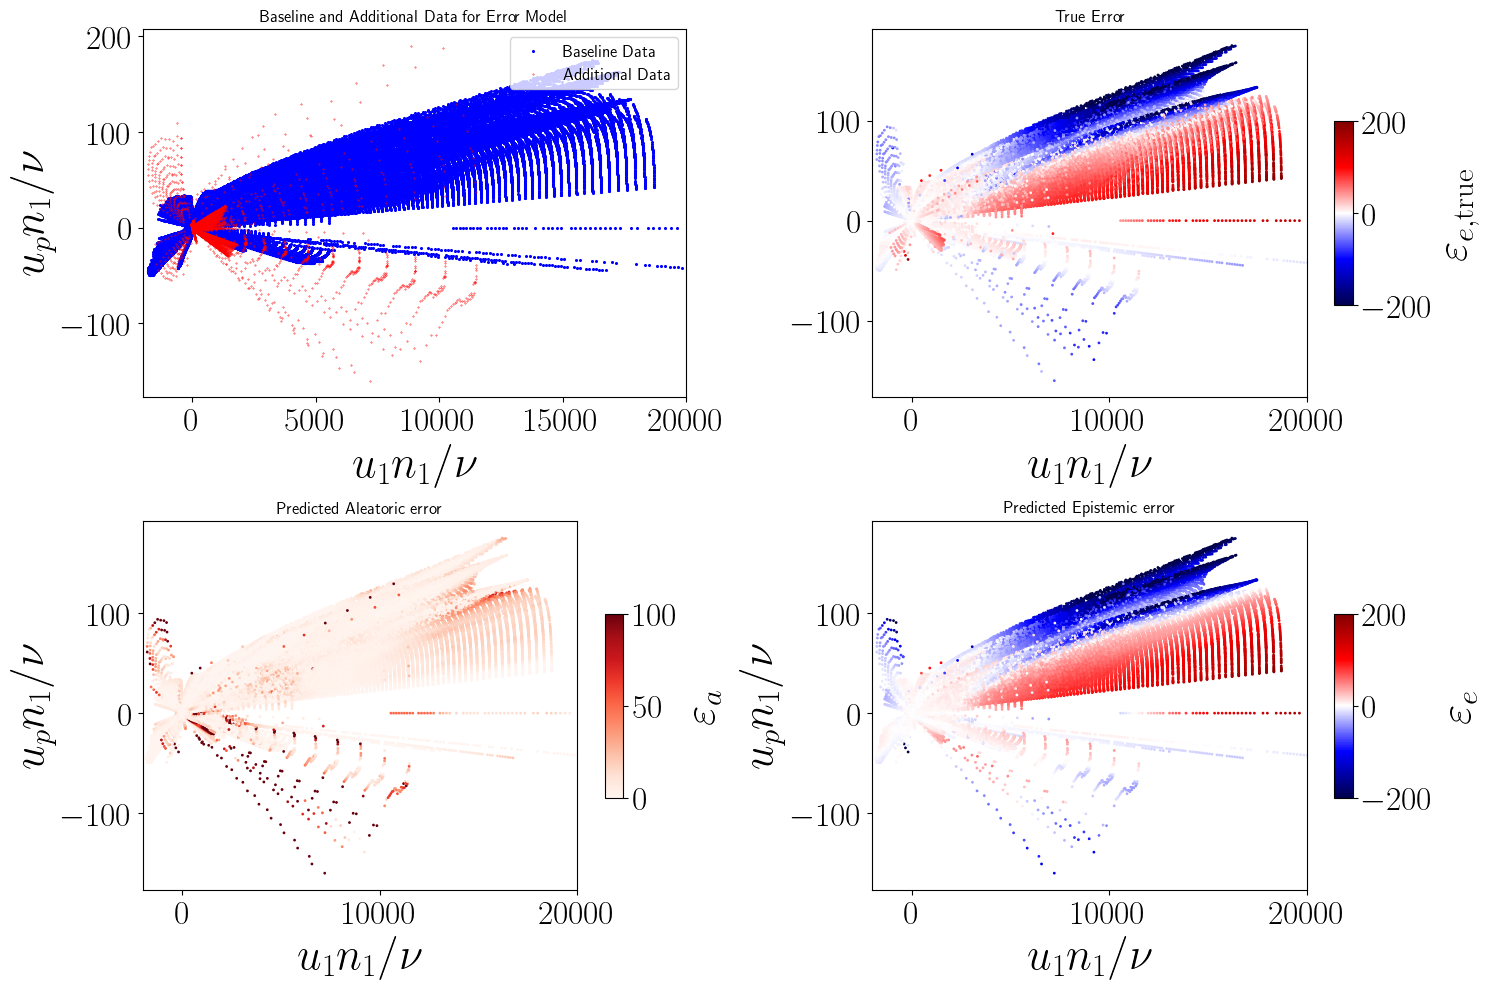

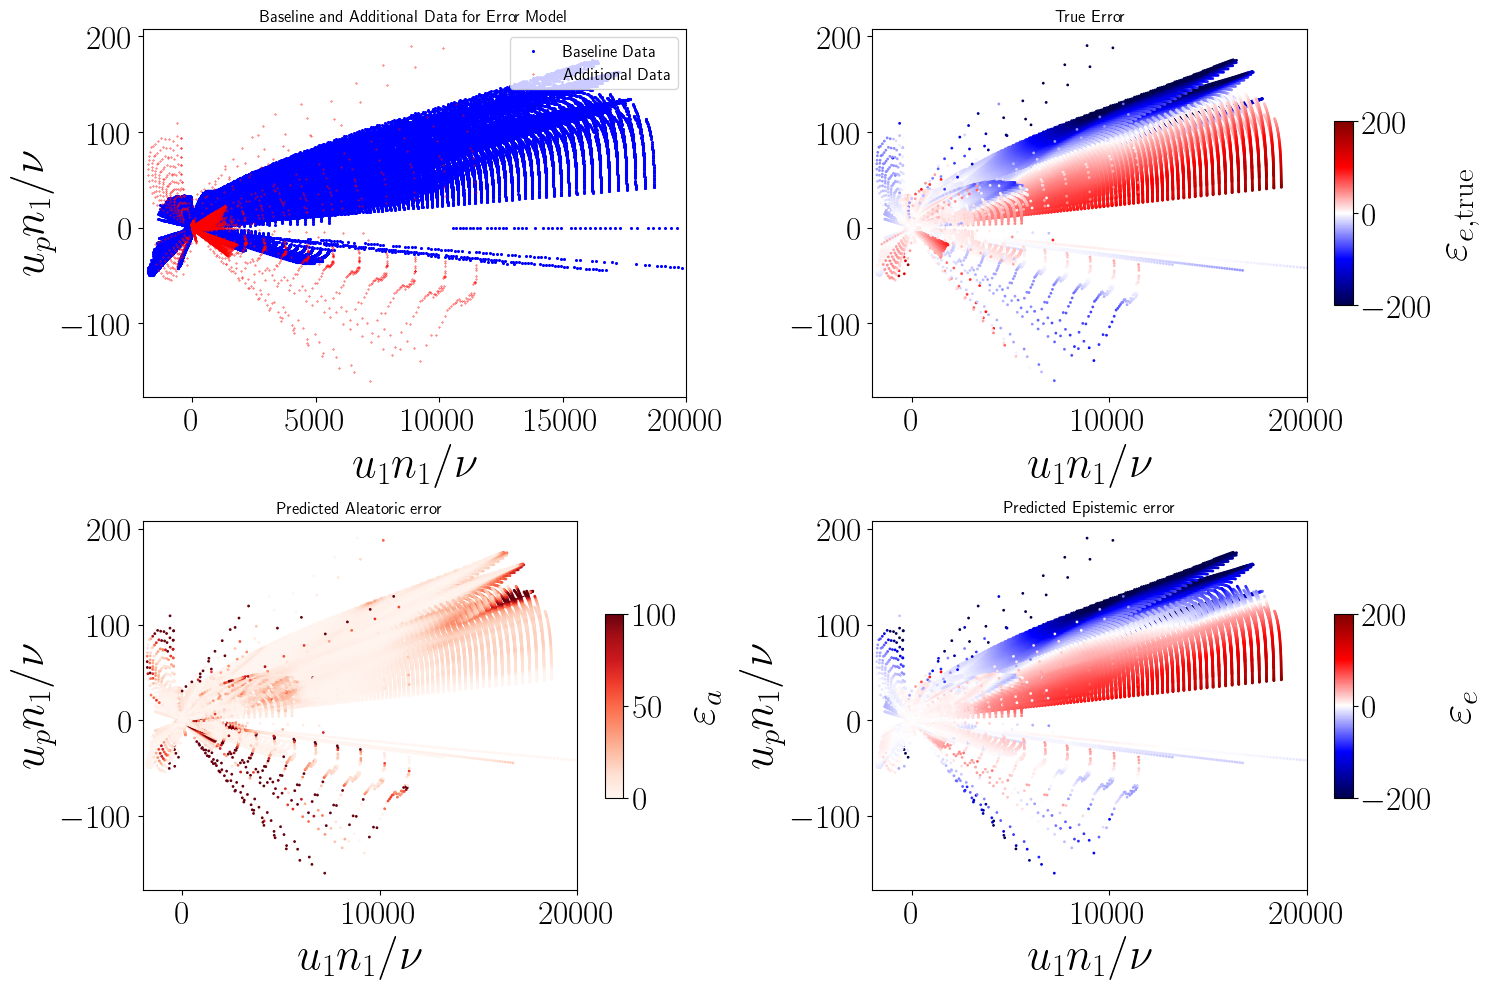

In [ ]:
# Absolute error for low aleatoric uncertainty
plot_error_distribution(X_train, X_extra, X_error_train_low, error_train_low, error_pred_mean_train_low, error_pred_std_train_low)
plot_error_distribution(X_train, X_extra, X_test_all, error_test, error_pred_mean_test_low, error_pred_std_test_low)

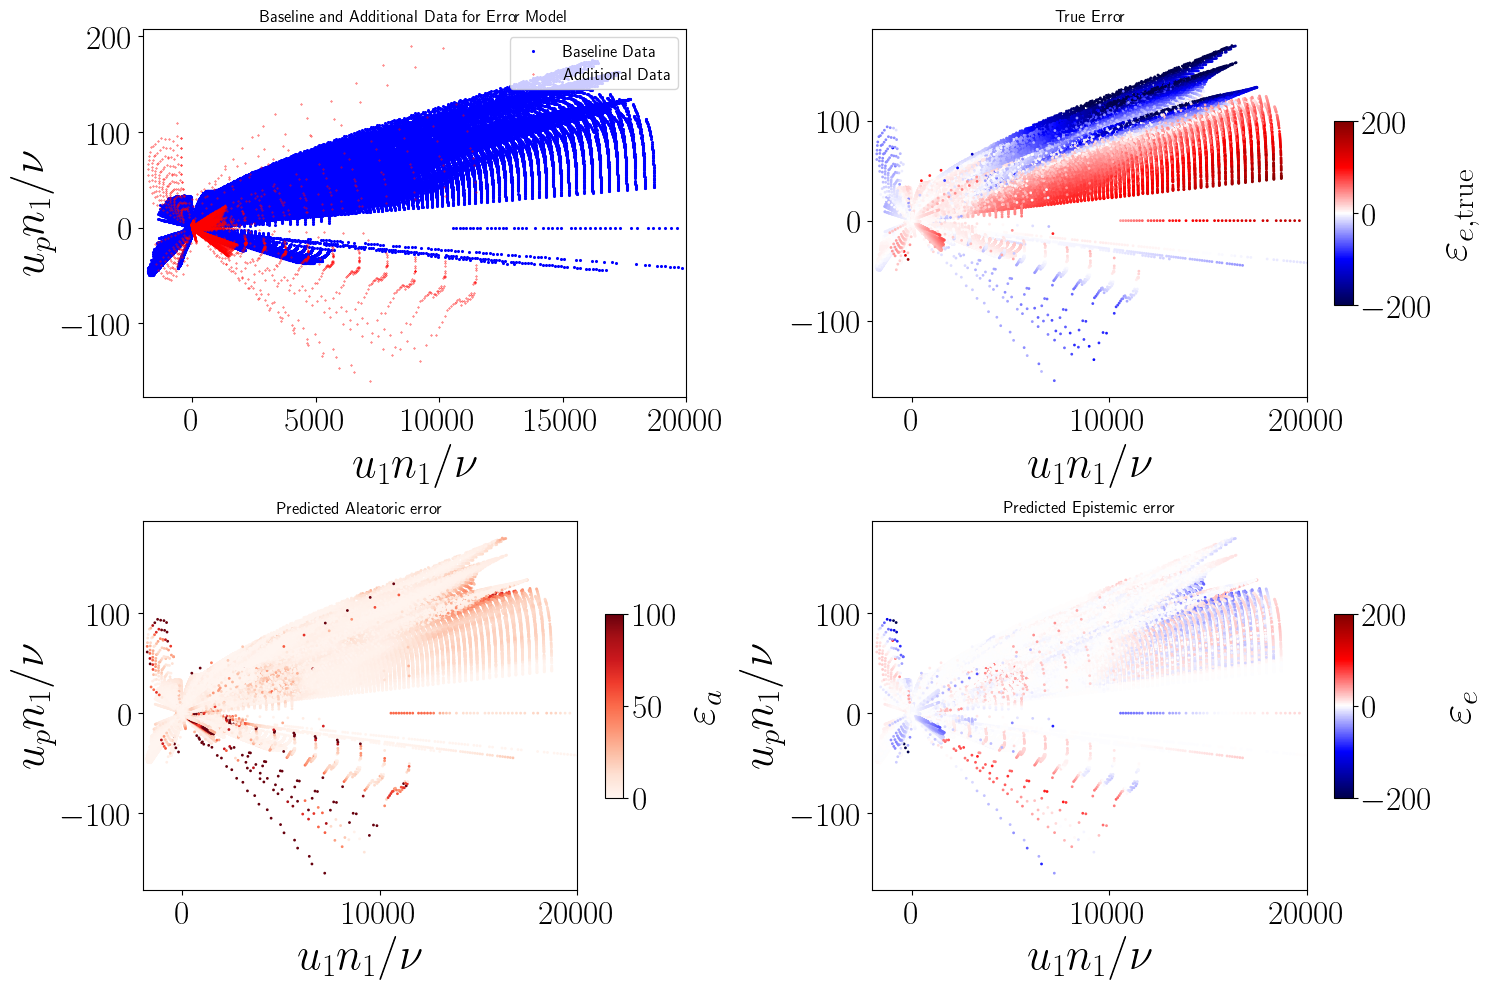

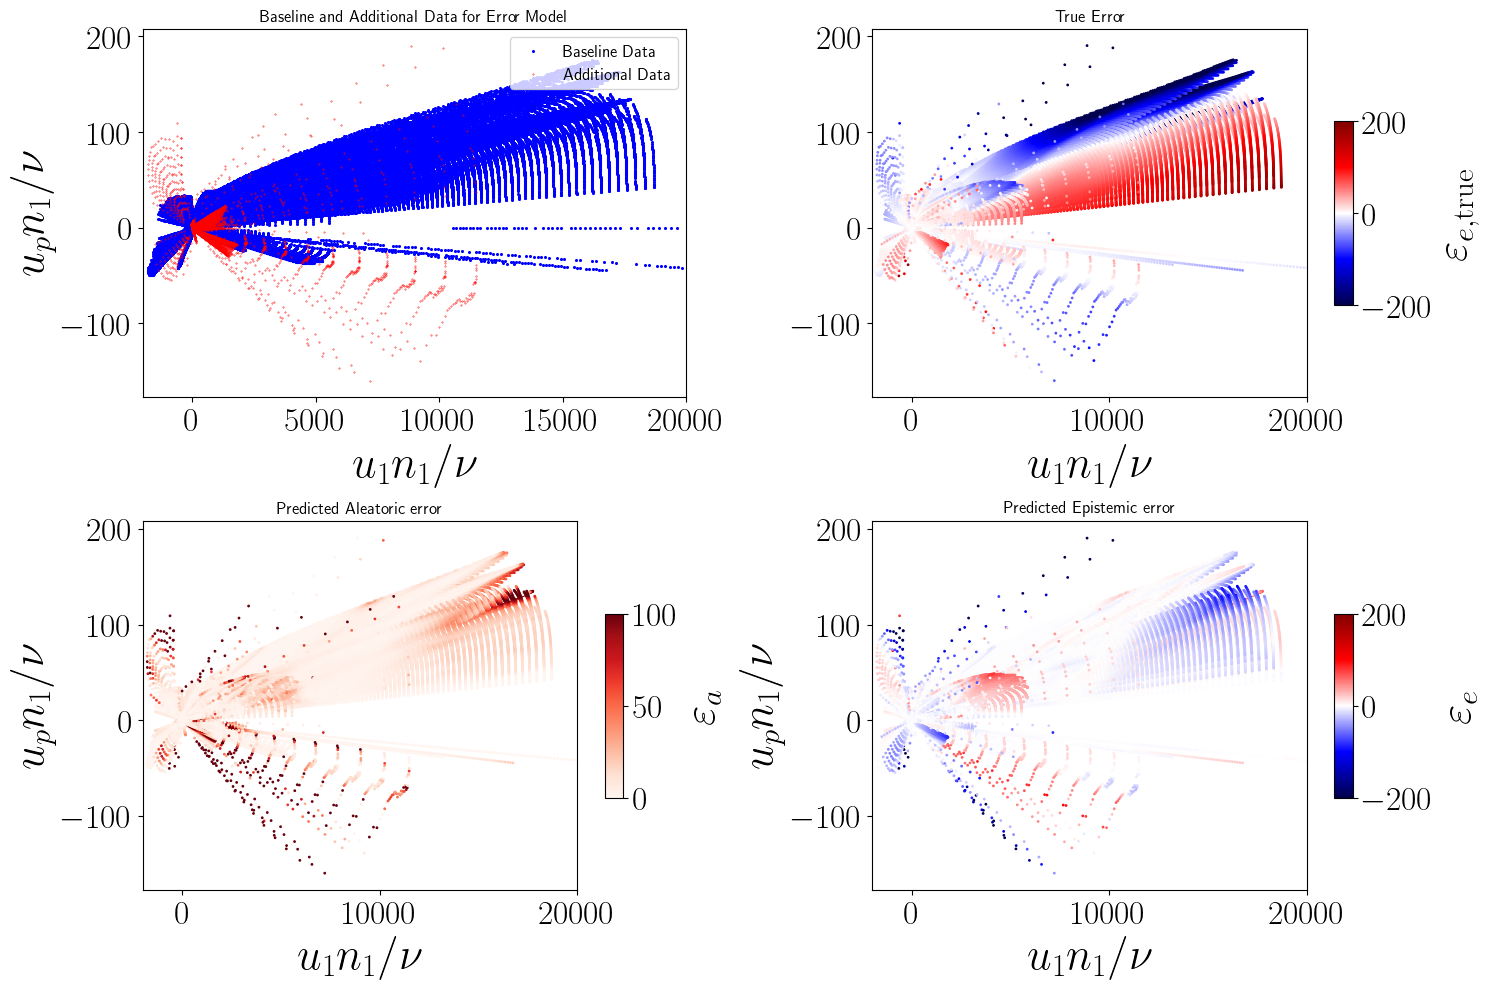

In [ ]:
# CORRECTION TO BASELINE PRED

# Predict corrected train and test output for low aleatoric uncertainty
y_corrected_train_low = y_error_train_pred_low + error_pred_mean_train_low
y_corrected_test_low = y_pred_test + error_pred_mean_test_low

# Calculate absolute error for corrected train and test output
error_corrected_train_low = y_corrected_train_low - y_error_train_low
error_corrected_test_low  = y_corrected_test_low  - y_test_all

# Plot corrected test data for low aleatoric uncertainty

plot_error_distribution(X_train, X_extra, X_error_train_low, error_train_low, error_corrected_train_low, error_pred_std_train_low)       #train
plot_error_distribution(X_train, X_extra, X_test_all,    error_test,       error_corrected_test_low,  error_pred_std_test_low)       #test

## Additional plotting for Error

In [33]:
# Define vizualization data

# x_viz = X_error_train
# x_unnormalized_viz = X_error_train_unnormalized
# y_viz = y_error_train
# y_pred_viz = y_error_train_pred
# y_corr_viz = y_corrected_train

x_viz = X_test_all
x_unnormalized_viz = unnormalized_inputs_test_all
y_viz = y_test_all
y_pred_viz = y_pred_test
y_corr_viz = y_corrected_test         # choose from original error_model or error_model_low
flow_type_viz = flow_type_test_all

In [34]:
# Compute log-law baseline predictions
loglaw_preds = np.zeros_like(y_viz)
for i in range(len(y_viz)):
    y_val  = x_unnormalized_viz[i, 0]
    nu_val = x_unnormalized_viz[i, 2]
    u_val  = abs(x_unnormalized_viz[i, 1])  # use abs as in baseline
    loglaw_preds[i] = model._eqwm_solve(y_val, nu_val, u_val)

/home/ihayat/work_dir/git_repo/BFM_WM/src/baseline_models.py:27: RuntimeWarning: invalid value encountered in log
  eq = u / utau - B - 1 / KAPPA * np.log(y * utau / nu)
/home/ihayat/work_dir/git_repo/BFM_WM/src/baseline_models.py:60: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol = fsolve(log_law, initial, args=(y, nu, u))


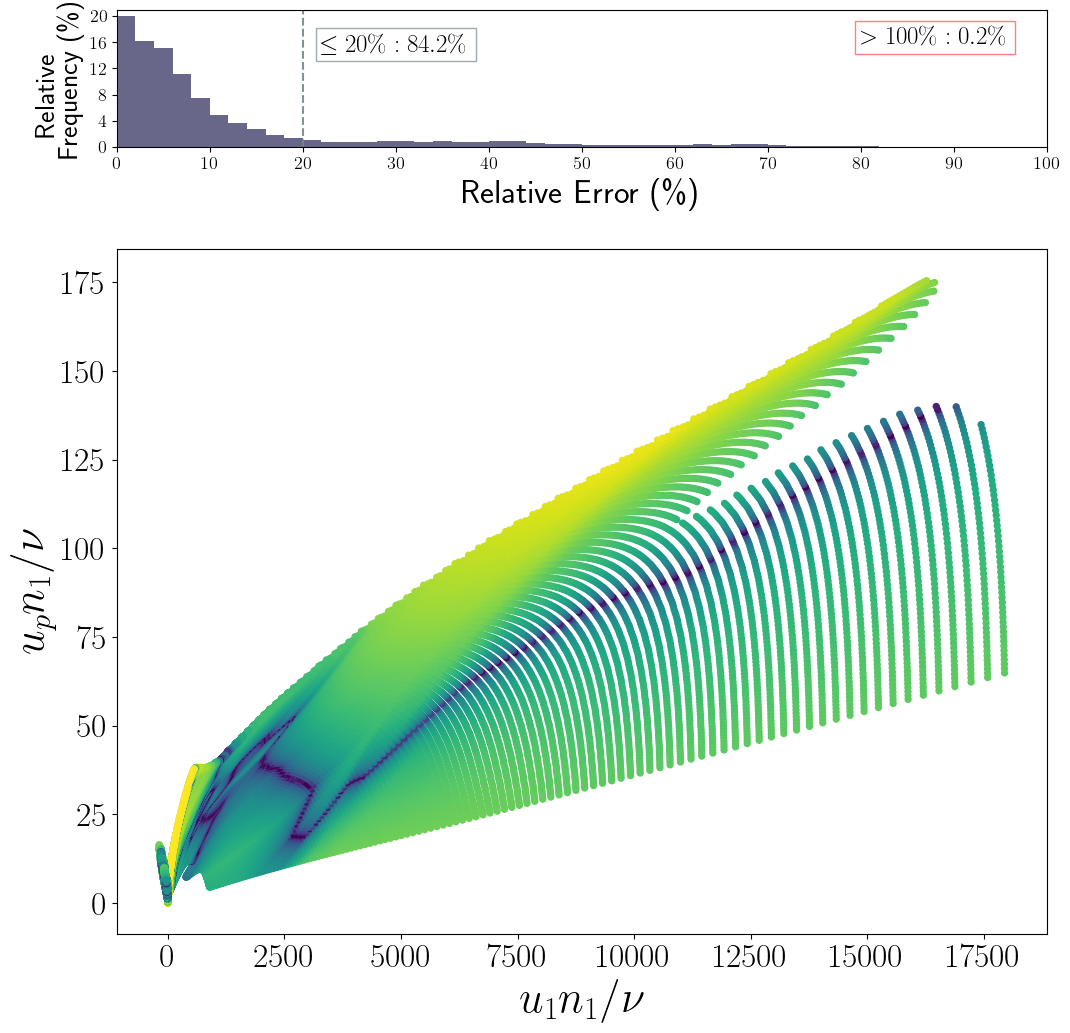

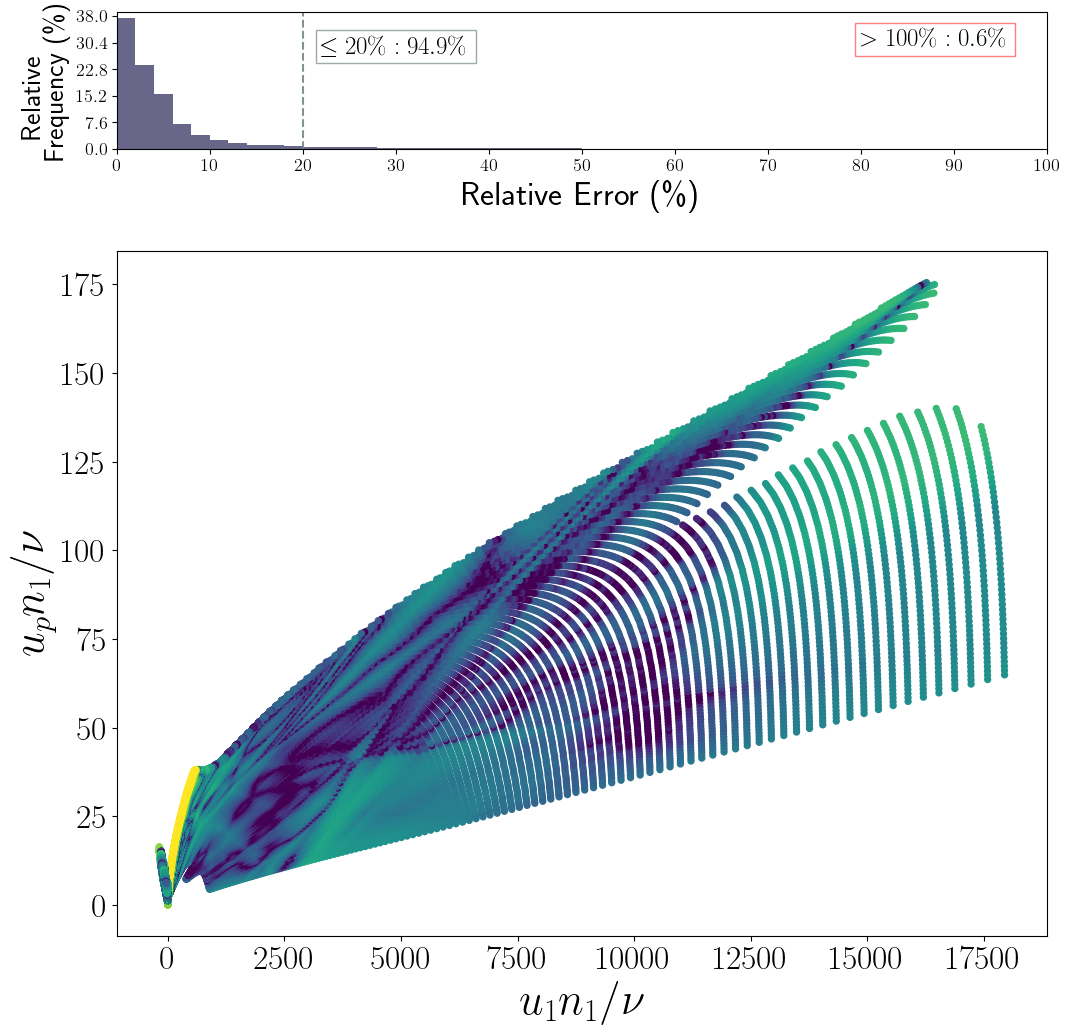

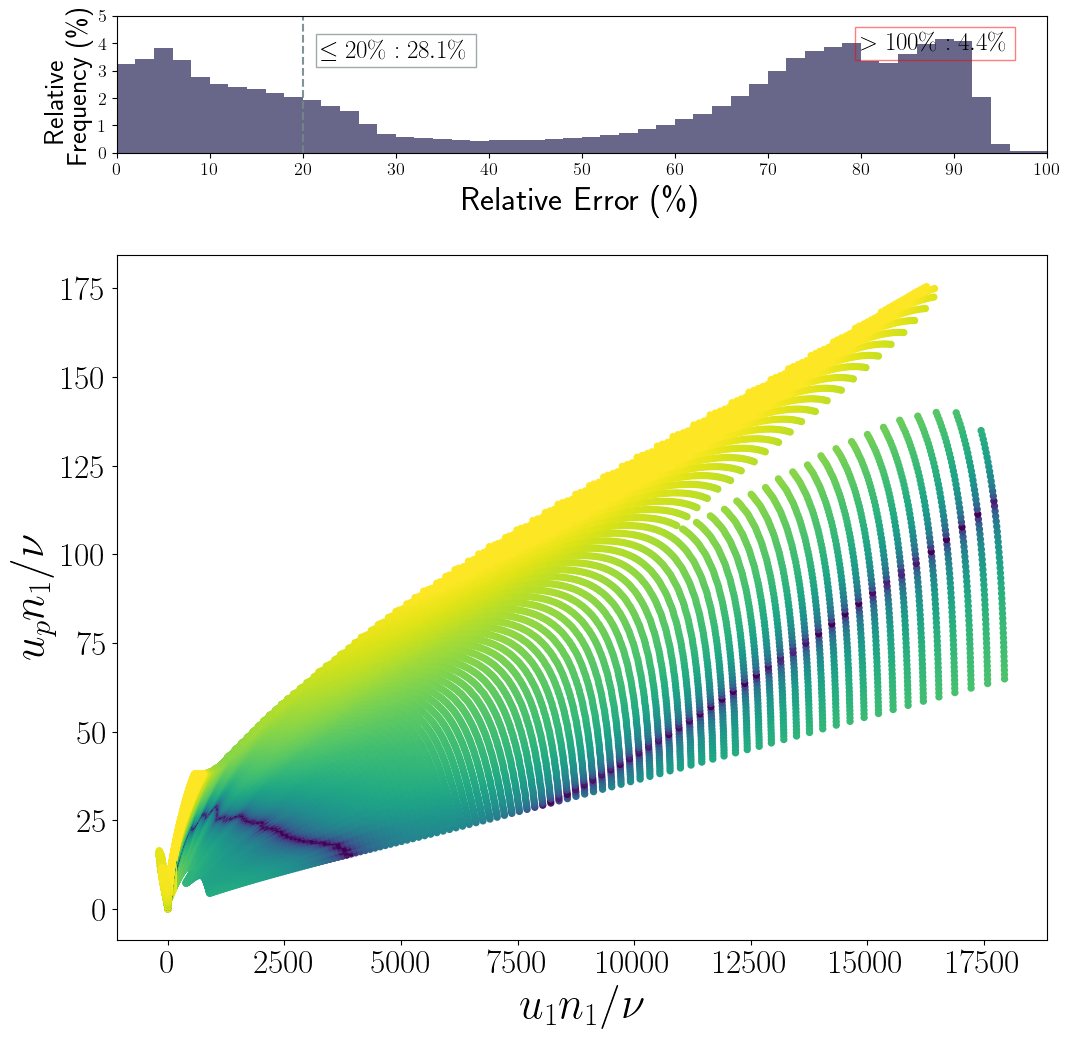

In [35]:
from visualization import WallModelVisualization

# Create visualization object
visualizer = WallModelVisualization(dataset_labels=None)

# Set output directory
results_dir = './results_corrected'
os.makedirs(results_dir, exist_ok=True)

# --- Plot for baseline WM predictions ---
_, _, _, rel_err_mean_basline, rel_err_std_basline = visualizer.plot_results_scatter_error(
    inputs=x_viz,
    output=y_pred_viz,
    output_true=y_viz,
    dataset="Baseline_WM",
    unnormalized_inputs=x_unnormalized_viz,
    flow_type=flow_type_viz,
    # save_path=results_dir,
)

# --- Plot for corrected WM predictions ---
_, _, _, rel_err_mean_corrected, rel_err_std_corrected = visualizer.plot_results_scatter_error(
    inputs=x_viz,
    output=y_corr_viz,
    output_true=y_viz,
    dataset="Error-Corrected_WM",
    unnormalized_inputs=x_unnormalized_viz,
    flow_type=flow_type_viz,
    # save_path=results_dir,
)

_, _, rel_err_mean_loglaw, rel_err_std_loglaw = visualizer.plot_results_scatter_error_loglaw(
    inputs=x_viz,
    log_predictions=loglaw_preds,
    output_true=y_viz,
    dataset="Log_Law_Bar",
    unnormalized_inputs=x_unnormalized_viz,
    flow_type=flow_type_viz,
    # save_path=results_dir
)


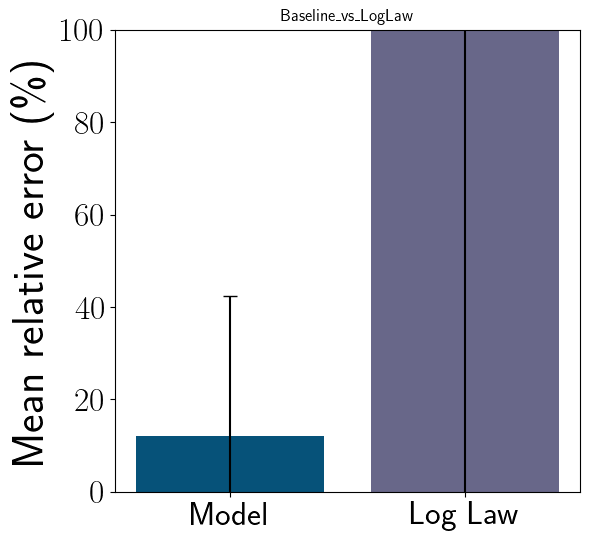

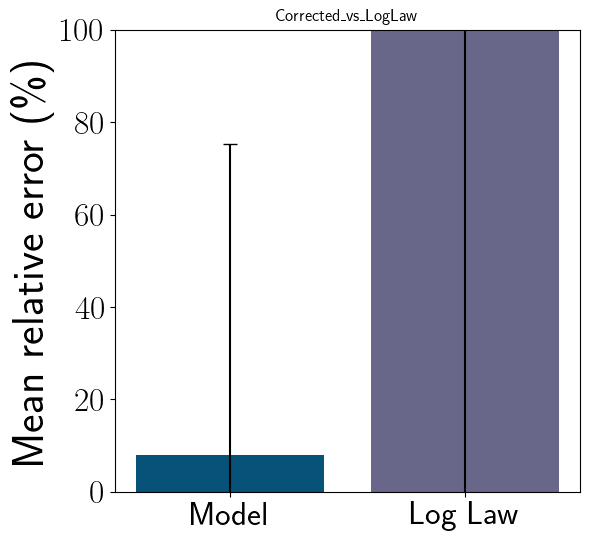

In [38]:
# Generate and save the bar chart comparison
visualizer.plot_comparison_bar_chart(
    model_mean=rel_err_mean_basline,
    model_std=rel_err_std_basline,
    loglaw_mean=rel_err_mean_loglaw,
    loglaw_std=rel_err_std_loglaw,
    dataset="Baseline_vs_LogLaw",
    # save_path="./results_corrected"
)

visualizer.plot_comparison_bar_chart(
    model_mean=rel_err_mean_corrected,
    model_std=rel_err_std_corrected,
    loglaw_mean=rel_err_mean_loglaw,
    loglaw_std=rel_err_std_loglaw,
    dataset="Corrected_vs_LogLaw",
    # save_path="./results_corrected"
)

In [39]:
def plot_error_3d(X_baseline, X_extra, X_test, error_test_perc, error_pred_mean_test_perc, error_pred_std_test_perc, elev=30, azim=-60):

    fig, ax = plt.subplots(2,2, figsize=(15, 10), subplot_kw={'projection': '3d'})
    ax[0,0].scatter(X_baseline[:,0], X_baseline[:,2], X_baseline[:,1], color='blue', s=1, alpha=1.0, label='Baseline Data')
    ax[0,0].scatter(X_extra[:,0],    X_extra[:,2],    X_extra[:,1],    color='red',  s=1, alpha=1.0, label='Additional Data')
    ax[0,0].set_title("Baseline and Additional Data for Error Model")
    ax[0,0].set_xlabel(r"$u_1 n_1 / \nu$"); ax[0,0].set_ylabel(r"$u_2 n_1 / \nu$"); ax[0,0].set_zlabel(r"$u_p n_1 / \nu$")
    ax[0,0].legend(loc='upper right', fontsize=12)

    sc1=ax[0,1].scatter(X_test[:,0], X_test[:,2], X_test[:,1], c=error_test_perc,  cmap='seismic', s=1, alpha=1.0)
    ax[0,1].set_title("True Error")
    ax[0,1].set_xlabel(r"$u_1 n_1 / \nu$"); ax[0,0].set_ylabel(r"$u_2 n_1 / \nu$"); ax[0,1].set_zlabel(r"$u_p n_1 / \nu$")
    fig.colorbar(sc1, ax=ax[0,1], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\% ~ \varepsilon_{e, \rm{true}}$")
    sc1.set_clim(-100, 100)

    sc2=ax[1,1].scatter(X_test[:,0], X_test[:,2], X_test[:,1], c=error_pred_mean_test_perc, cmap='seismic', s=1, alpha=1.0)
    ax[1,1].set_title("Predicted Epistemic error")
    ax[1,1].set_xlabel(r"$u_1 n_1 / \nu$"); ax[1,1].set_ylabel(r"$u_2 n_1 / \nu$"); ax[1,1].set_zlabel(r"$u_p n_1 / \nu$")
    fig.colorbar(sc2, ax=ax[1,1], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\% ~ \varepsilon_{e}$")
    sc2.set_clim(-100, 100)

    sc3=ax[1,0].scatter(X_test[:,0], X_test[:,2], X_test[:,1], c=error_pred_std_test_perc, cmap='Reds', s=1, alpha=1.0)
    ax[1,0].set_title("Predicted Aleatoric error")
    ax[1,0].set_xlabel(r"$u_1 n_1 / \nu$"); ax[1,0].set_ylabel(r"$u_2 n_1 / \nu$"); ax[1,0].set_zlabel(r"$u_p n_1 / \nu$")
    fig.colorbar(sc3, ax=ax[1,0], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\% ~ \varepsilon_{a}$")
    sc3.set_clim(0, 100)

    ax[0,0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax[0,0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax[0,0].ticklabel_format(style='sci', axis='z', scilimits=(0,0))
    ax[0,1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax[0,1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax[0,1].ticklabel_format(style='sci', axis='z', scilimits=(0,0))
    ax[1,0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax[1,0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax[1,0].ticklabel_format(style='sci', axis='z', scilimits=(0,0))
    ax[1,1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax[1,1].ticklabel_format(style='sci', axis='z', scilimits=(0,0))

    # change angles of the axes
    ax[0,0].view_init(elev=elev, azim=azim)
    ax[0,1].view_init(elev=elev, azim=azim)
    ax[1,0].view_init(elev=elev, azim=azim)
    ax[1,1].view_init(elev=elev, azim=azim)

    # plt.tight_layout()
    plt.show()

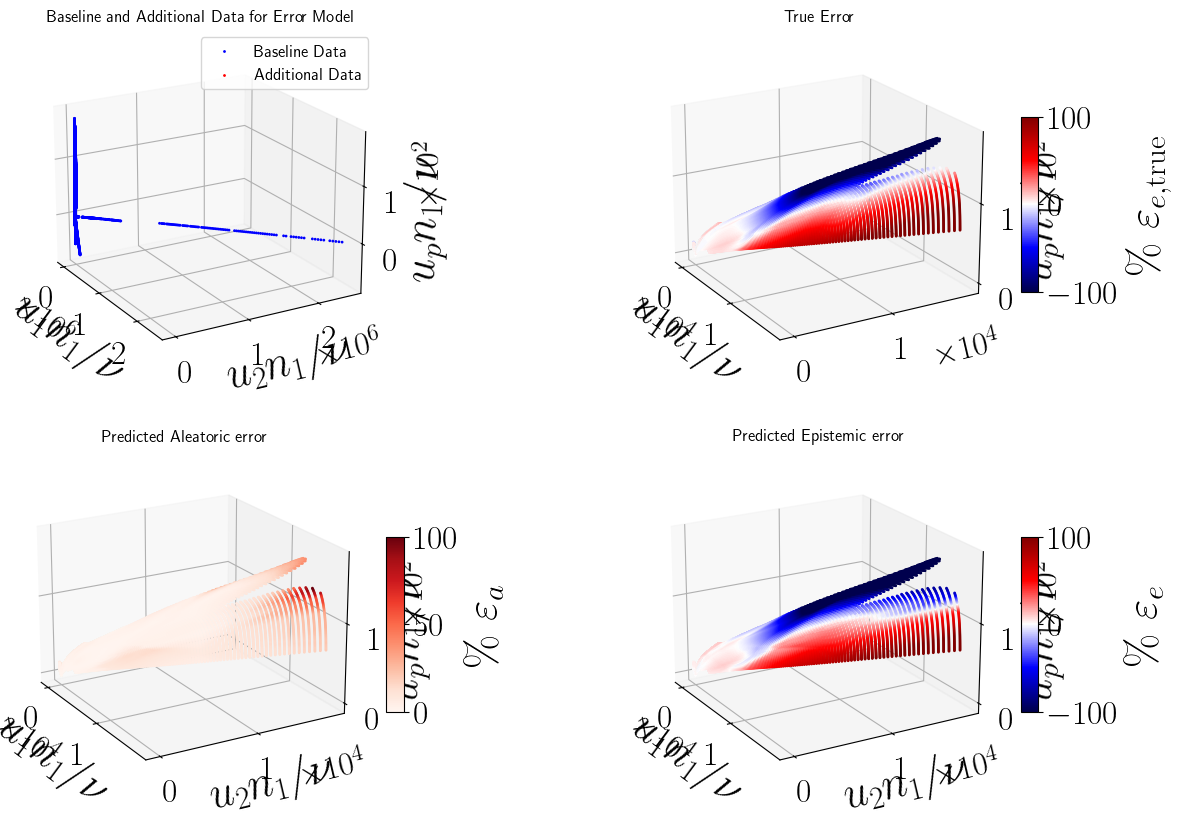

In [40]:
# 3D Plot training data predictions
# plot_error_3d(X_train, X_extra, X_test_all, error_test_perc, error_pred_mean_test_perc, error_pred_std_test_perc, elev=20, azim=-30)

plot_error_3d(X_train, X_extra, X_test_all, error_test,      error_pred_mean_test,      error_pred_std_test,      elev=20, azim=-30)

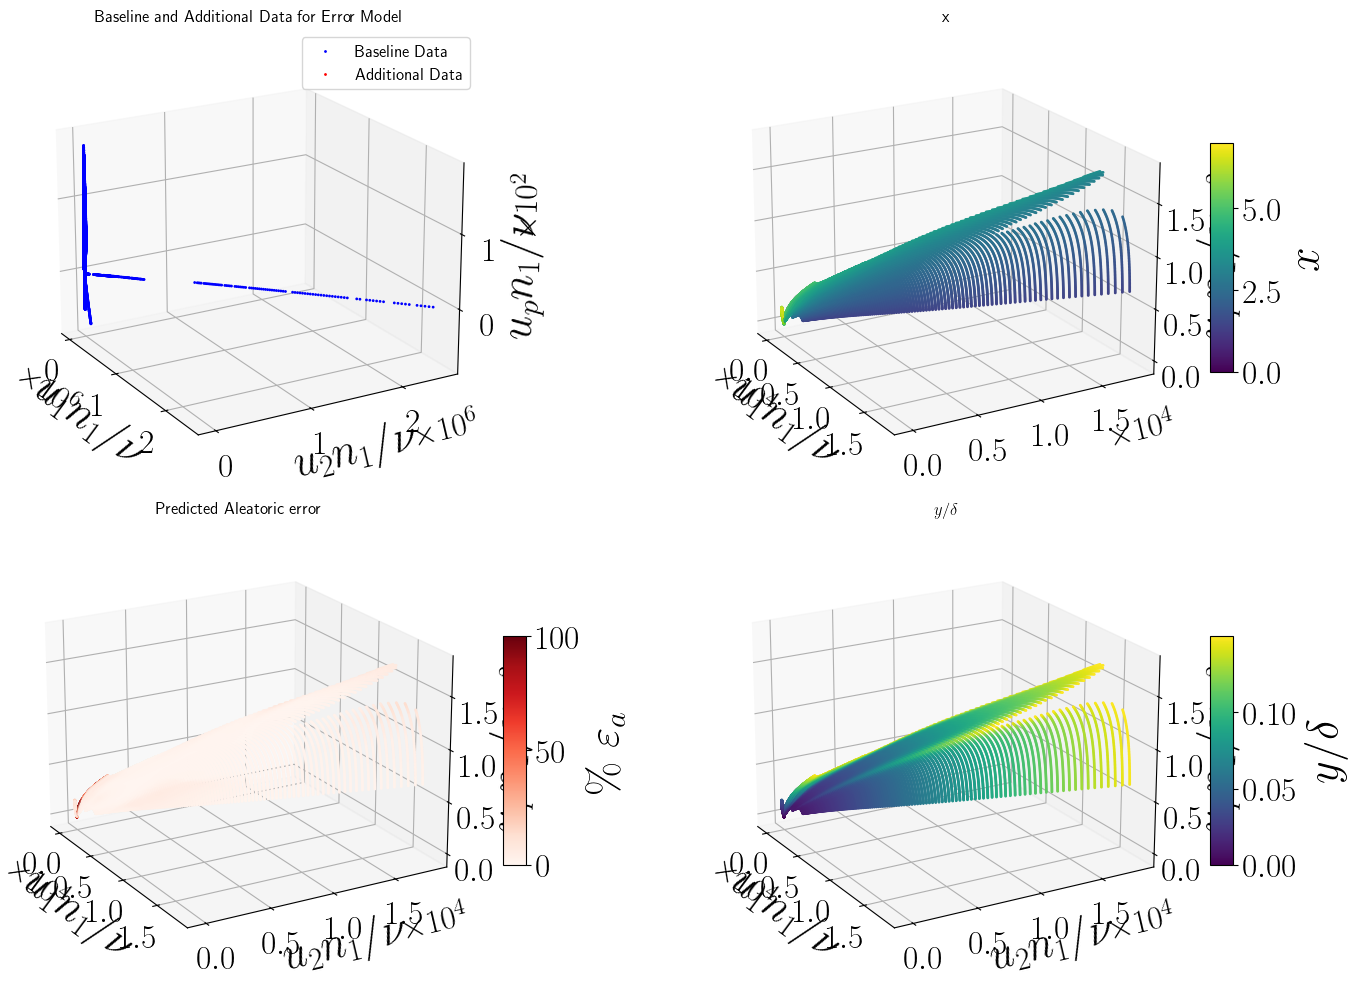

In [41]:
# 3D Plot x and y coords

def plot_error_3d_coords(X_baseline, X_extra, X_test, xcoord_test, ydelta_test, error_pred_std_test_perc, elev=30, azim=-60):

    fig, ax = plt.subplots(2,2, figsize=(15, 10), subplot_kw={'projection': '3d'})
    ax[0,0].scatter(X_baseline[:,0], X_baseline[:,2], X_baseline[:,1], color='blue', s=1, alpha=1.0, label='Baseline Data')
    ax[0,0].scatter(X_extra[:,0],    X_extra[:,2],    X_extra[:,1],    color='red',  s=1, alpha=1.0, label='Additional Data')
    ax[0,0].set_title("Baseline and Additional Data for Error Model")
    ax[0,0].set_xlabel(r"$u_1 n_1 / \nu$"); ax[0,0].set_ylabel(r"$u_2 n_1 / \nu$"); ax[0,0].set_zlabel(r"$u_p n_1 / \nu$")
    ax[0,0].legend(loc='upper right', fontsize=12)

    sc1=ax[0,1].scatter(X_test[:,0], X_test[:,2], X_test[:,1], c=xcoord_test,  cmap='viridis', s=1, alpha=1.0)
    ax[0,1].set_title("x")
    ax[0,1].set_xlabel(r"$u_1 n_1 / \nu$"); ax[0,0].set_ylabel(r"$u_2 n_1 / \nu$"); ax[0,1].set_zlabel(r"$u_p n_1 / \nu$")
    fig.colorbar(sc1, ax=ax[0,1], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$x$")
    sc1.set_clim(0, np.max(xcoord_test))

    sc2=ax[1,1].scatter(X_test[:,0], X_test[:,2], X_test[:,1], c=ydelta_test, cmap='viridis', s=1, alpha=1.0)
    ax[1,1].set_title(r"$y/\delta$")
    ax[1,1].set_xlabel(r"$u_1 n_1 / \nu$"); ax[1,1].set_ylabel(r"$u_2 n_1 / \nu$"); ax[1,1].set_zlabel(r"$u_p n_1 / \nu$")
    fig.colorbar(sc2, ax=ax[1,1], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$y/\delta$")
    sc2.set_clim(0, np.max(ydelta_test))

    sc3=ax[1,0].scatter(X_test[:,0], X_test[:,2], X_test[:,1], c=error_pred_std_test_perc, cmap='Reds', s=1, alpha=1.0)
    ax[1,0].set_title("Predicted Aleatoric error")
    ax[1,0].set_xlabel(r"$u_1 n_1 / \nu$"); ax[1,0].set_ylabel(r"$u_2 n_1 / \nu$"); ax[1,0].set_zlabel(r"$u_p n_1 / \nu$")
    fig.colorbar(sc3, ax=ax[1,0], shrink=0.5, aspect=10, orientation='vertical').set_label(r"$\% ~ \varepsilon_{a}$")
    sc3.set_clim(0, 100)

    ax[0,0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax[0,0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax[0,0].ticklabel_format(style='sci', axis='z', scilimits=(0,0))
    ax[0,1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax[0,1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax[0,1].ticklabel_format(style='sci', axis='z', scilimits=(0,0))
    ax[1,0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax[1,0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax[1,0].ticklabel_format(style='sci', axis='z', scilimits=(0,0))
    ax[1,1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax[1,1].ticklabel_format(style='sci', axis='z', scilimits=(0,0))

    # change angles of the axes
    ax[0,0].view_init(elev=elev, azim=azim)
    ax[0,1].view_init(elev=elev, azim=azim)
    ax[1,0].view_init(elev=elev, azim=azim)
    ax[1,1].view_init(elev=elev, azim=azim)

    plt.tight_layout()
    plt.show()

plot_error_3d_coords(X_train, X_extra, X_test_all, xcoord_test, ydelta_test, error_pred_std_test_perc, elev=20, azim=-30)